# If necessary install the below packages (libraries) before loading them
Use install.packages in terminal rather than in the notebook.

`mamba activate r432
R
install.packages()`

In [175]:
# Downstream analysis using object created by Sara Grimm
# Match the R version and important package versions used in the original analysis
# R432

library(Seurat);       # v5.0.1  
library(ggplot2);      # v3.4.4
library(dplyr);
library(viridis);
library(dittoSeq);
library(scales);
library(scCustomize)
library(tidyr)
library(stringr)
library(ComplexHeatmap)

Warning message:
“package ‘stringr’ was built under R version 4.3.3”
Loading required package: grid

ComplexHeatmap version 2.21.2
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))




In [176]:
# Record active package versions
packageVersion("Seurat");
packageVersion("ggplot2");        
packageVersion("dplyr");
packageVersion("viridis");
packageVersion("dittoSeq");
packageVersion("scales");
packageVersion("scCustomize");
packageVersion("tidyr");
packageVersion("stringr");
packageVersion("ComplexHeatmap");

[1] ‘5.0.1’

[1] ‘3.4.4’

[1] ‘1.1.4’

[1] ‘0.6.5’

[1] ‘1.14.3’

[1] ‘1.3.0’

[1] ‘3.0.1’

[1] ‘1.3.1’

[1] ‘1.5.1’

[1] ‘2.21.2’

In [6]:
# Read in the processed RDS file from Sara Grimm, which is the human endometrial cell atlas non-hormone treated (HECA-NH) seurat object.
# See prep code: "step0-make_NonHormoneDonor_HECA_object.Rtxt"
hecaNH <- readRDS("/ddn/gs1/home/marquardtrm/PRcreSRF_scRNAseq_Sara/data_rds/hecaNH_integration.31mar2025.rds")

hecaNH
head(hecaNH)

An object of class Seurat 
17736 features across 260576 samples within 1 assay 
Active assay: RNA (17736 features, 2000 variable features)
 3 layers present: data, counts, scale.data
 5 dimensional reductions calculated: scVI, umap, pca, integrated.rpca, integrated.umap

,n_genes,sample,library,Processing,Treatment,percent_mito,n_counts,scrublet_score,genotype,Library_genotype,⋯,lineage,label_long,orig.ident,nCount_RNA,nFeature_RNA,Hormonal_treatment,Tenx_kit,Binary_Stage,binary_pathology,celltypeCollapsed
,<int>,<fct>,<fct>,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<fct>,<fct>,⋯,<fct>,<fct>,<fct>,<dbl>,<dbl>,<fct>,<fct>,<fct>,<fct>,<fct>
HCA_A_RepT_RNA13247830_AAACCTGAGCGATGAC-Mareckova,1981,HCA_A_RepT_RNA13247830,HCA_A_RepT_RNA13247830,Fresh,Coll.+Trypsin,0.03678274,3956,0.03315650,A70,HCA_A_RepT_RNA13247830_A70,⋯,Mesenchymal,19 | ePV 1a,HCA,3956,1901,nan,3' v3.1,Proliferative,Stage0,Periv
HCA_A_RepT_RNA13247830_AAACCTGAGCTAGGCA-Mareckova,3492,HCA_A_RepT_RNA13247830,HCA_A_RepT_RNA13247830,Fresh,Coll.+Trypsin,0.04224921,9546,0.02918782,A70,HCA_A_RepT_RNA13247830_A70,⋯,Mesenchymal,23 | eStromal,HCA,9546,3336,nan,3' v3.1,Proliferative,Stage0,FibF2
HCA_A_RepT_RNA13247830_AAACCTGCACCAACCG-Mareckova,2967,HCA_A_RepT_RNA13247830,HCA_A_RepT_RNA13247830,Fresh,Coll.+Trypsin,0.09299796,7188,0.07558140,A70,HCA_A_RepT_RNA13247830_A70,⋯,Endothelial,32 | Venous,HCA,7188,2850,nan,3' v3.1,Proliferative,Stage0,Endo
HCA_A_RepT_RNA13247830_AAACCTGCACCTGGTG-Mareckova,2597,HCA_A_RepT_RNA13247830,HCA_A_RepT_RNA13247830,Fresh,Coll.+Trypsin,0.03544836,6029,0.06925208,A70,HCA_A_RepT_RNA13247830_A70,⋯,Mesenchymal,18 | mPV,HCA,6029,2484,nan,3' v3.1,Proliferative,Stage0,Periv
HCA_A_RepT_RNA13247830_AAACCTGCATAGAAAC-Mareckova,3319,HCA_A_RepT_RNA13247830,HCA_A_RepT_RNA13247830,Fresh,Coll.+Trypsin,0.03645893,8571,0.05496308,A70,HCA_A_RepT_RNA13247830_A70,⋯,Endothelial,32 | Venous,HCA,8571,3179,nan,3' v3.1,Proliferative,Stage0,Endo
HCA_A_RepT_RNA13247830_AAACCTGCATTTCAGG-Mareckova,3731,HCA_A_RepT_RNA13247830,HCA_A_RepT_RNA13247830,Fresh,Coll.+Trypsin,0.06638157,10053,0.08256881,A70,HCA_A_RepT_RNA13247830_A70,⋯,Endothelial,32 | Venous,HCA,10053,3570,nan,3' v3.1,Proliferative,Stage0,Endo
HCA_A_RepT_RNA13247830_AAACCTGGTGGTTTCA-Mareckova,3652,HCA_A_RepT_RNA13247830,HCA_A_RepT_RNA13247830,Fresh,Coll.+Trypsin,0.09278455,9636,0.04754601,A70,HCA_A_RepT_RNA13247830_A70,⋯,Mesenchymal,17 | uSMCs,HCA,9636,3461,nan,3' v3.1,Proliferative,Stage0,SMC
HCA_A_RepT_RNA13247830_AAACCTGTCAGCCTAA-Mareckova,2488,HCA_A_RepT_RNA13247830,HCA_A_RepT_RNA13247830,Fresh,Coll.+Trypsin,0.09697344,6364,0.04895105,A70,HCA_A_RepT_RNA13247830_A70,⋯,Mesenchymal,19 | ePV 1a,HCA,6364,2402,nan,3' v3.1,Proliferative,Stage0,Periv
HCA_A_RepT_RNA13247830_AAACCTGTCCAAGCCG-Mareckova,1804,HCA_A_RepT_RNA13247830,HCA_A_RepT_RNA13247830,Fresh,Coll.+Trypsin,0.09187965,3032,0.11220715,A70,HCA_A_RepT_RNA13247830_A70,⋯,Endothelial,32 | Venous,HCA,3032,1752,nan,3' v3.1,Proliferative,Stage0,Endo


In [10]:
levels(hecaNH$Binary_Stage)

[1] "Hormones"      "Menstrual"     "Proliferative" "Secretory"

In [15]:
table(hecaNH$binary_pathology,hecaNH$Binary_Stage);

         
          Hormones Menstrual Proliferative Secretory
  Stage0         0       625         70342     88937
  NonZero        0      3794         39089     57789

In [142]:
table(hecaNH$binary_pathology,hecaNH$celltypeCollapsed);

         
          Other ImmMyel ImmLymph EndoLymph  Endo Periv   SMC FibCyc FibF3 FibF2
  Stage0   9195    2848    11454       109  9045  7705  1374   3944   295 68336
  NonZero  9921    1694    14652        42  3822  3698     1   3189    89 43217
         
          EpiCyc EpiGlnd EpiLum
  Stage0    1546   30532  13521
  NonZero   2158   16376   1813

In [14]:
table(hecaNH$lineage,hecaNH$Binary_Stage);

             
              Hormones Menstrual Proliferative Secretory
  Endothelial        0       136          7074      5808
  Epithelial         0       262         21471     52510
  Immune             0      1908         17248     11492
  Mesenchymal        0      2113         63638     76916

In [292]:
table(hecaNH$Binary_Stage,hecaNH$celltypeCollapsed);

               
                Other ImmMyel ImmLymph EndoLymph  Endo Periv   SMC FibCyc FibF3
  Hormones          0       0        0         0     0     0     0      0     0
  Menstrual       208     276     1632         7   129   188     0     55     0
  Proliferative  4247    3270    13978        94  6980  6834   553   5350   340
  Secretory     14661     996    10496        50  5758  4381   822   1728    44
               
                FibF2 EpiCyc EpiGlnd EpiLum
  Hormones          0      0       0      0
  Menstrual      1861     10      24     29
  Proliferative 49964   2187   13409   2225
  Secretory     59728   1507   33475  13080

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



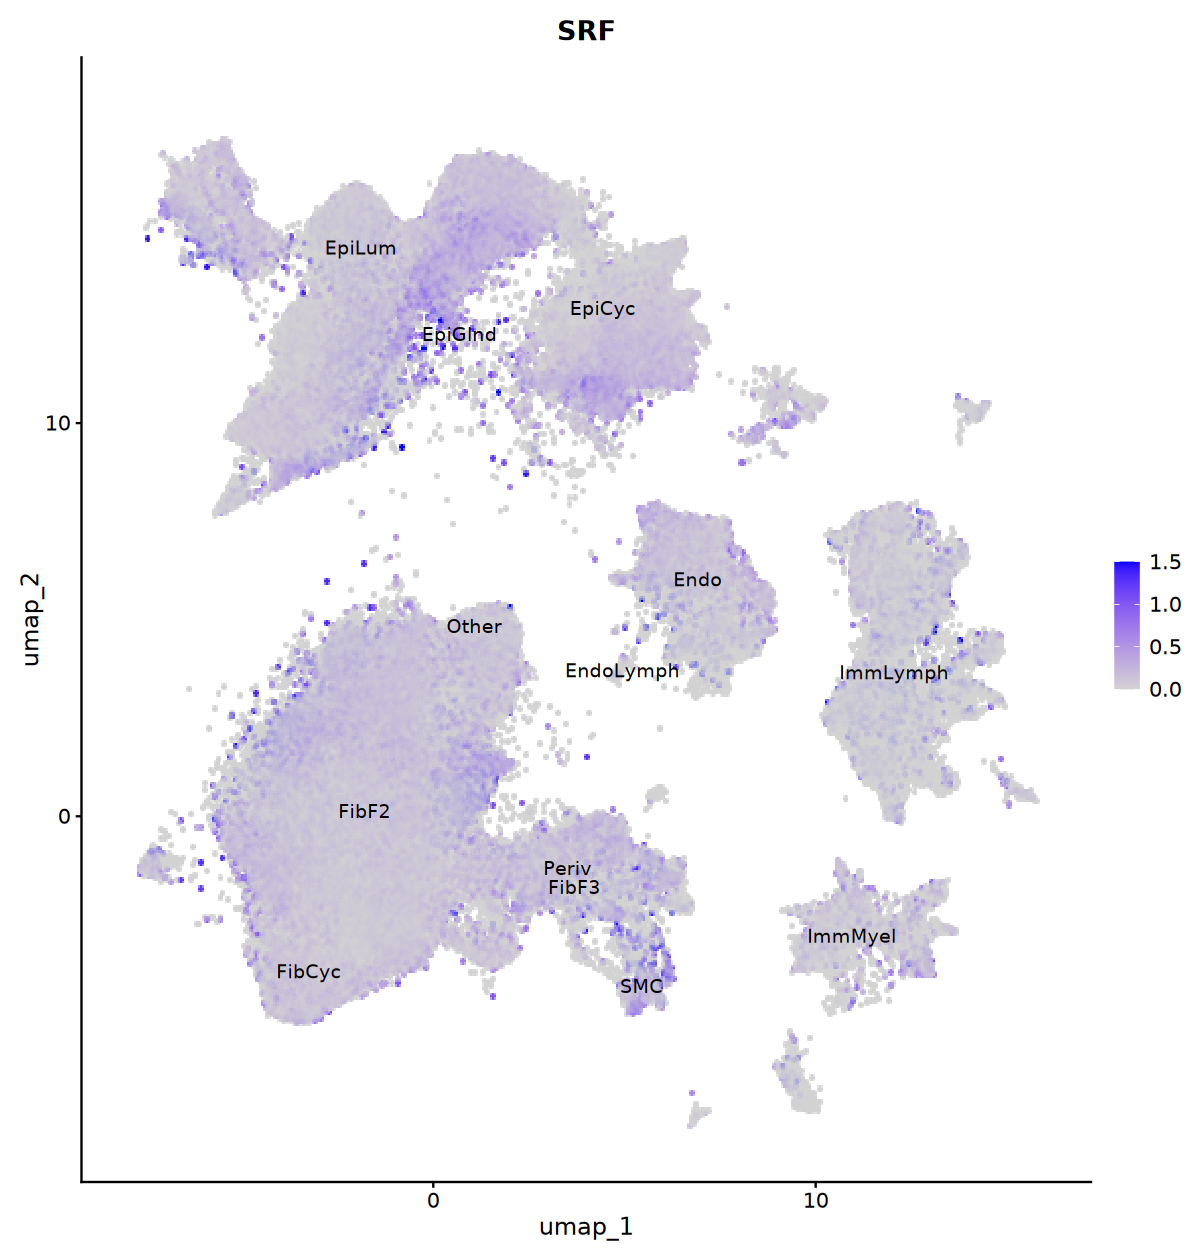

In [239]:
# Plot genes of interest

saved <- options(repr.plot.width = 10, repr.plot.height = 10.5) # Make the plots bigger from here on out, save old options
FeaturePlot(hecaNH,
            features = c('SRF'),
            label = TRUE, order = FALSE, min.cutoff = 0, max.cutoff = 1.5,
            pt.size = 2)  + theme(legend.position = "right")
options(saved) # restore old settings


Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



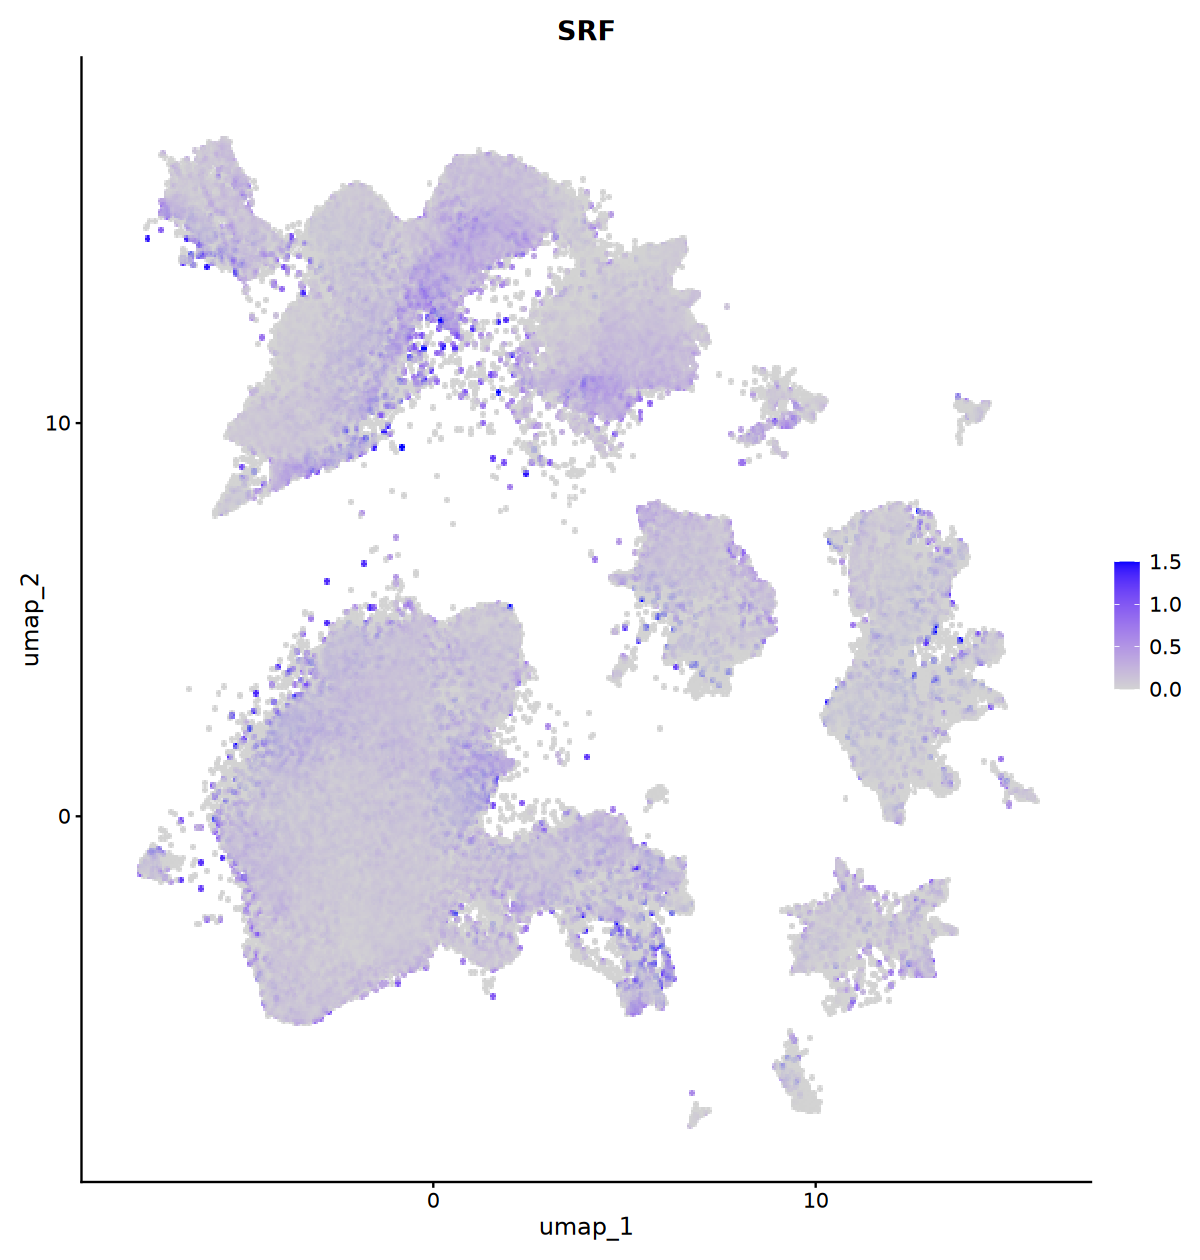

In [238]:
# Plot genes of interest

saved <- options(repr.plot.width = 10, repr.plot.height = 10.5) # Make the plots bigger from here on out, save old options
FeaturePlot(hecaNH,
            features = c('SRF'),
            label = FALSE, order = FALSE, min.cutoff = 0, max.cutoff = 1.5,
            pt.size = 2)  + theme(legend.position = "right")
options(saved) # restore old settings


Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



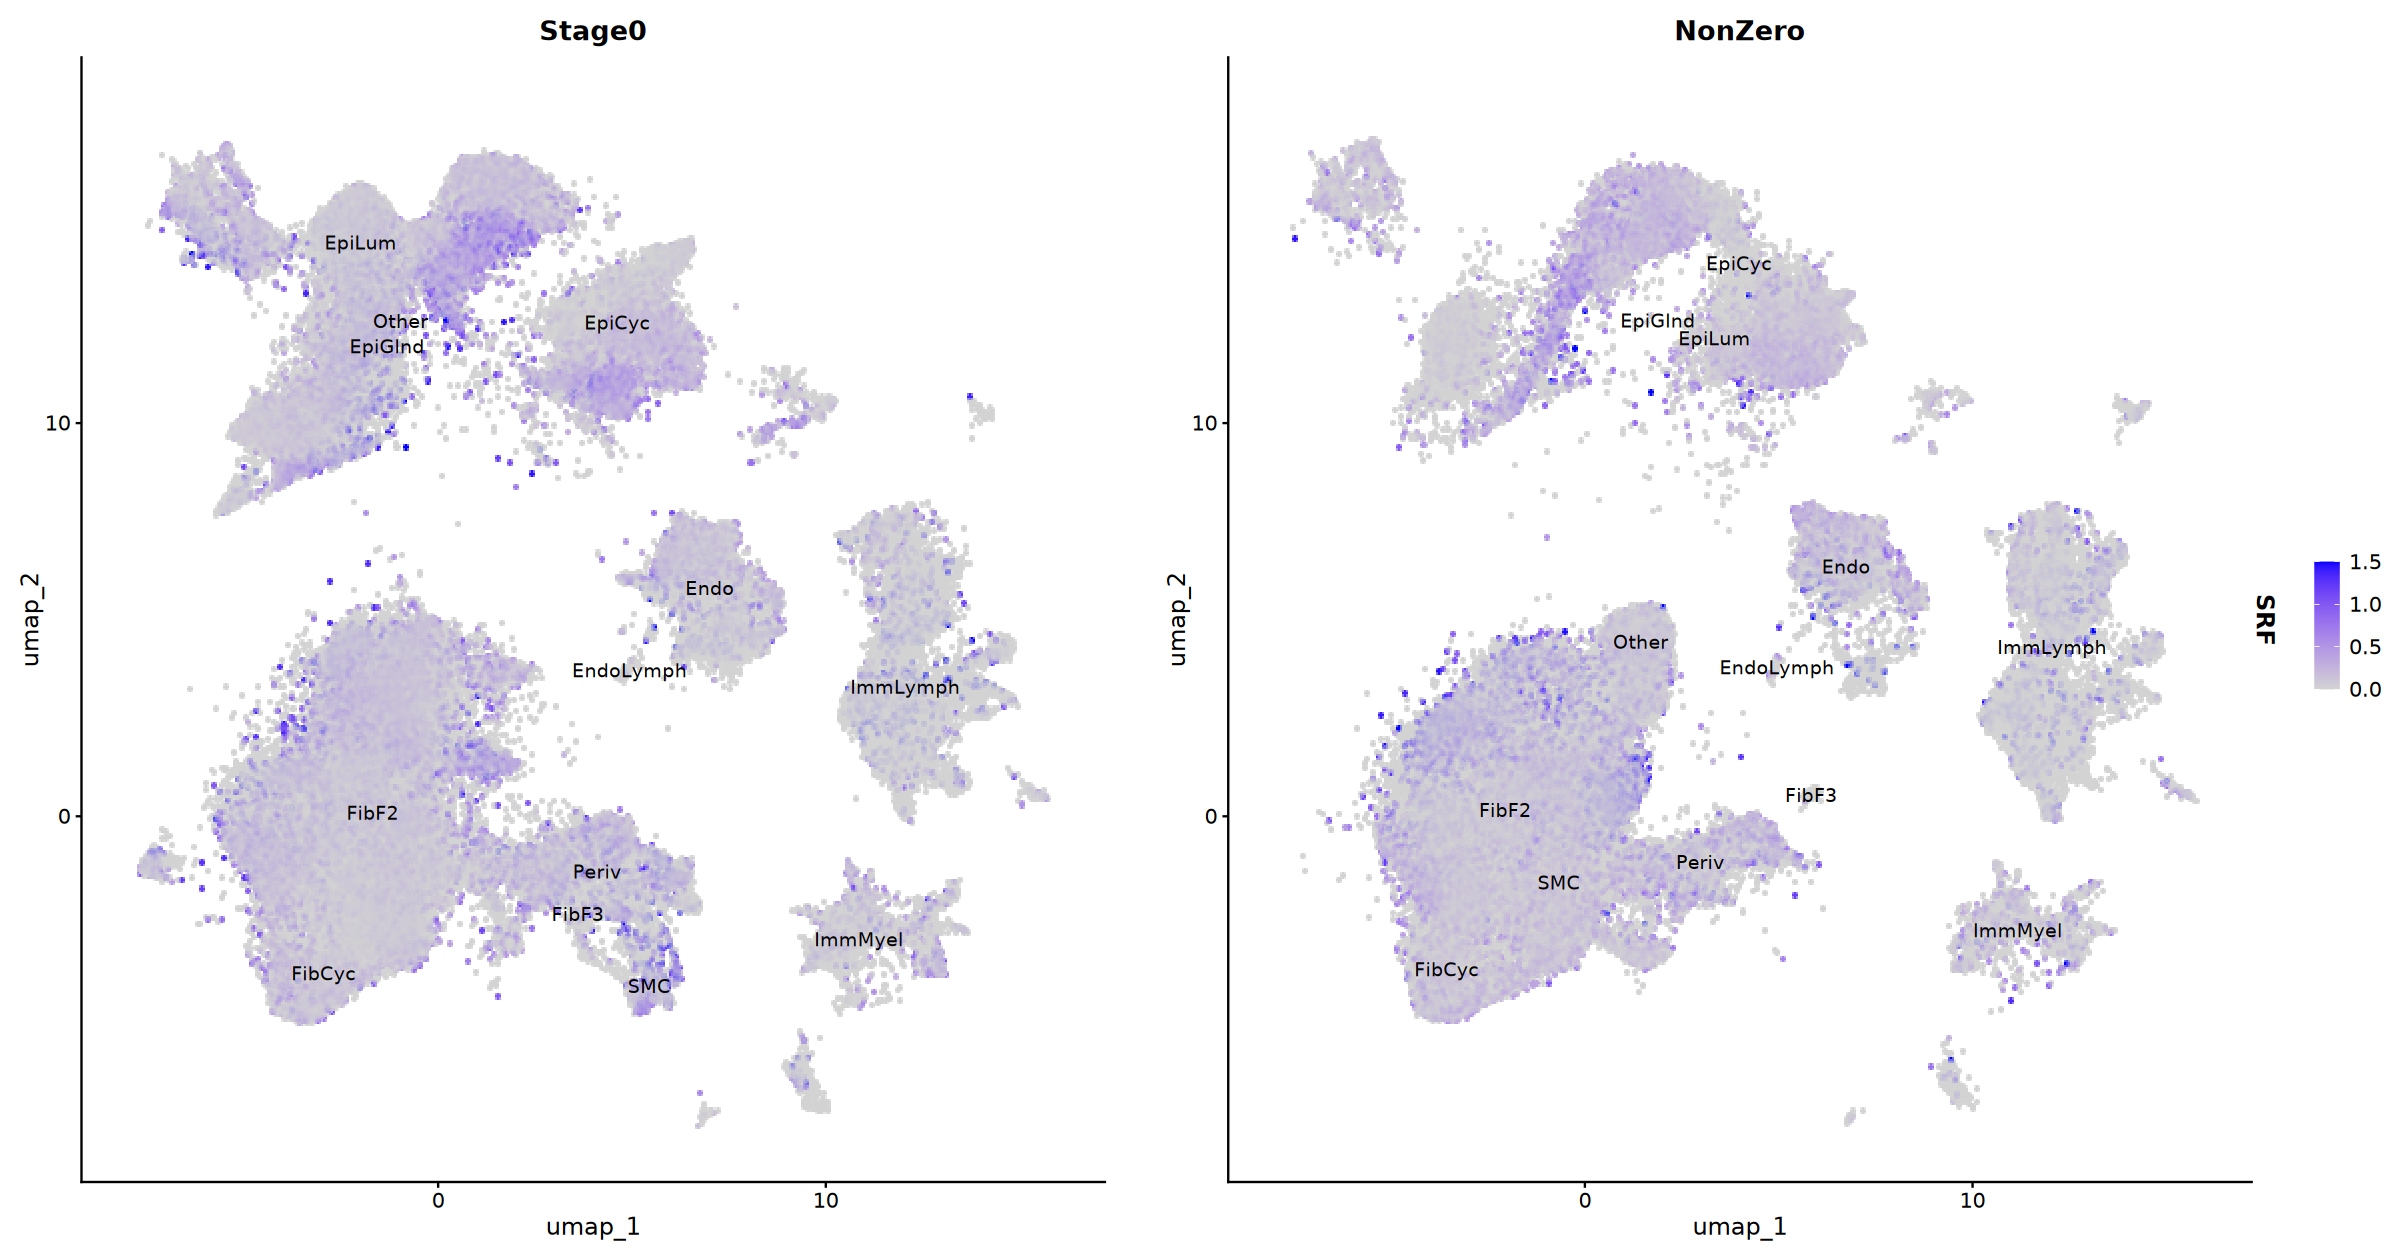

In [279]:
# Plot genes of interest

saved <- options(repr.plot.width = 20, repr.plot.height = 10.5) # Make the plots bigger from here on out, save old options
FeaturePlot(hecaNH,
            features = c('SRF'),
            split.by = "binary_pathology",
            label = TRUE, order = FALSE, min.cutoff = 0, max.cutoff = 1.5,
            pt.size = 2)  + theme(legend.position = "right")
options(saved) # restore old settings


Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



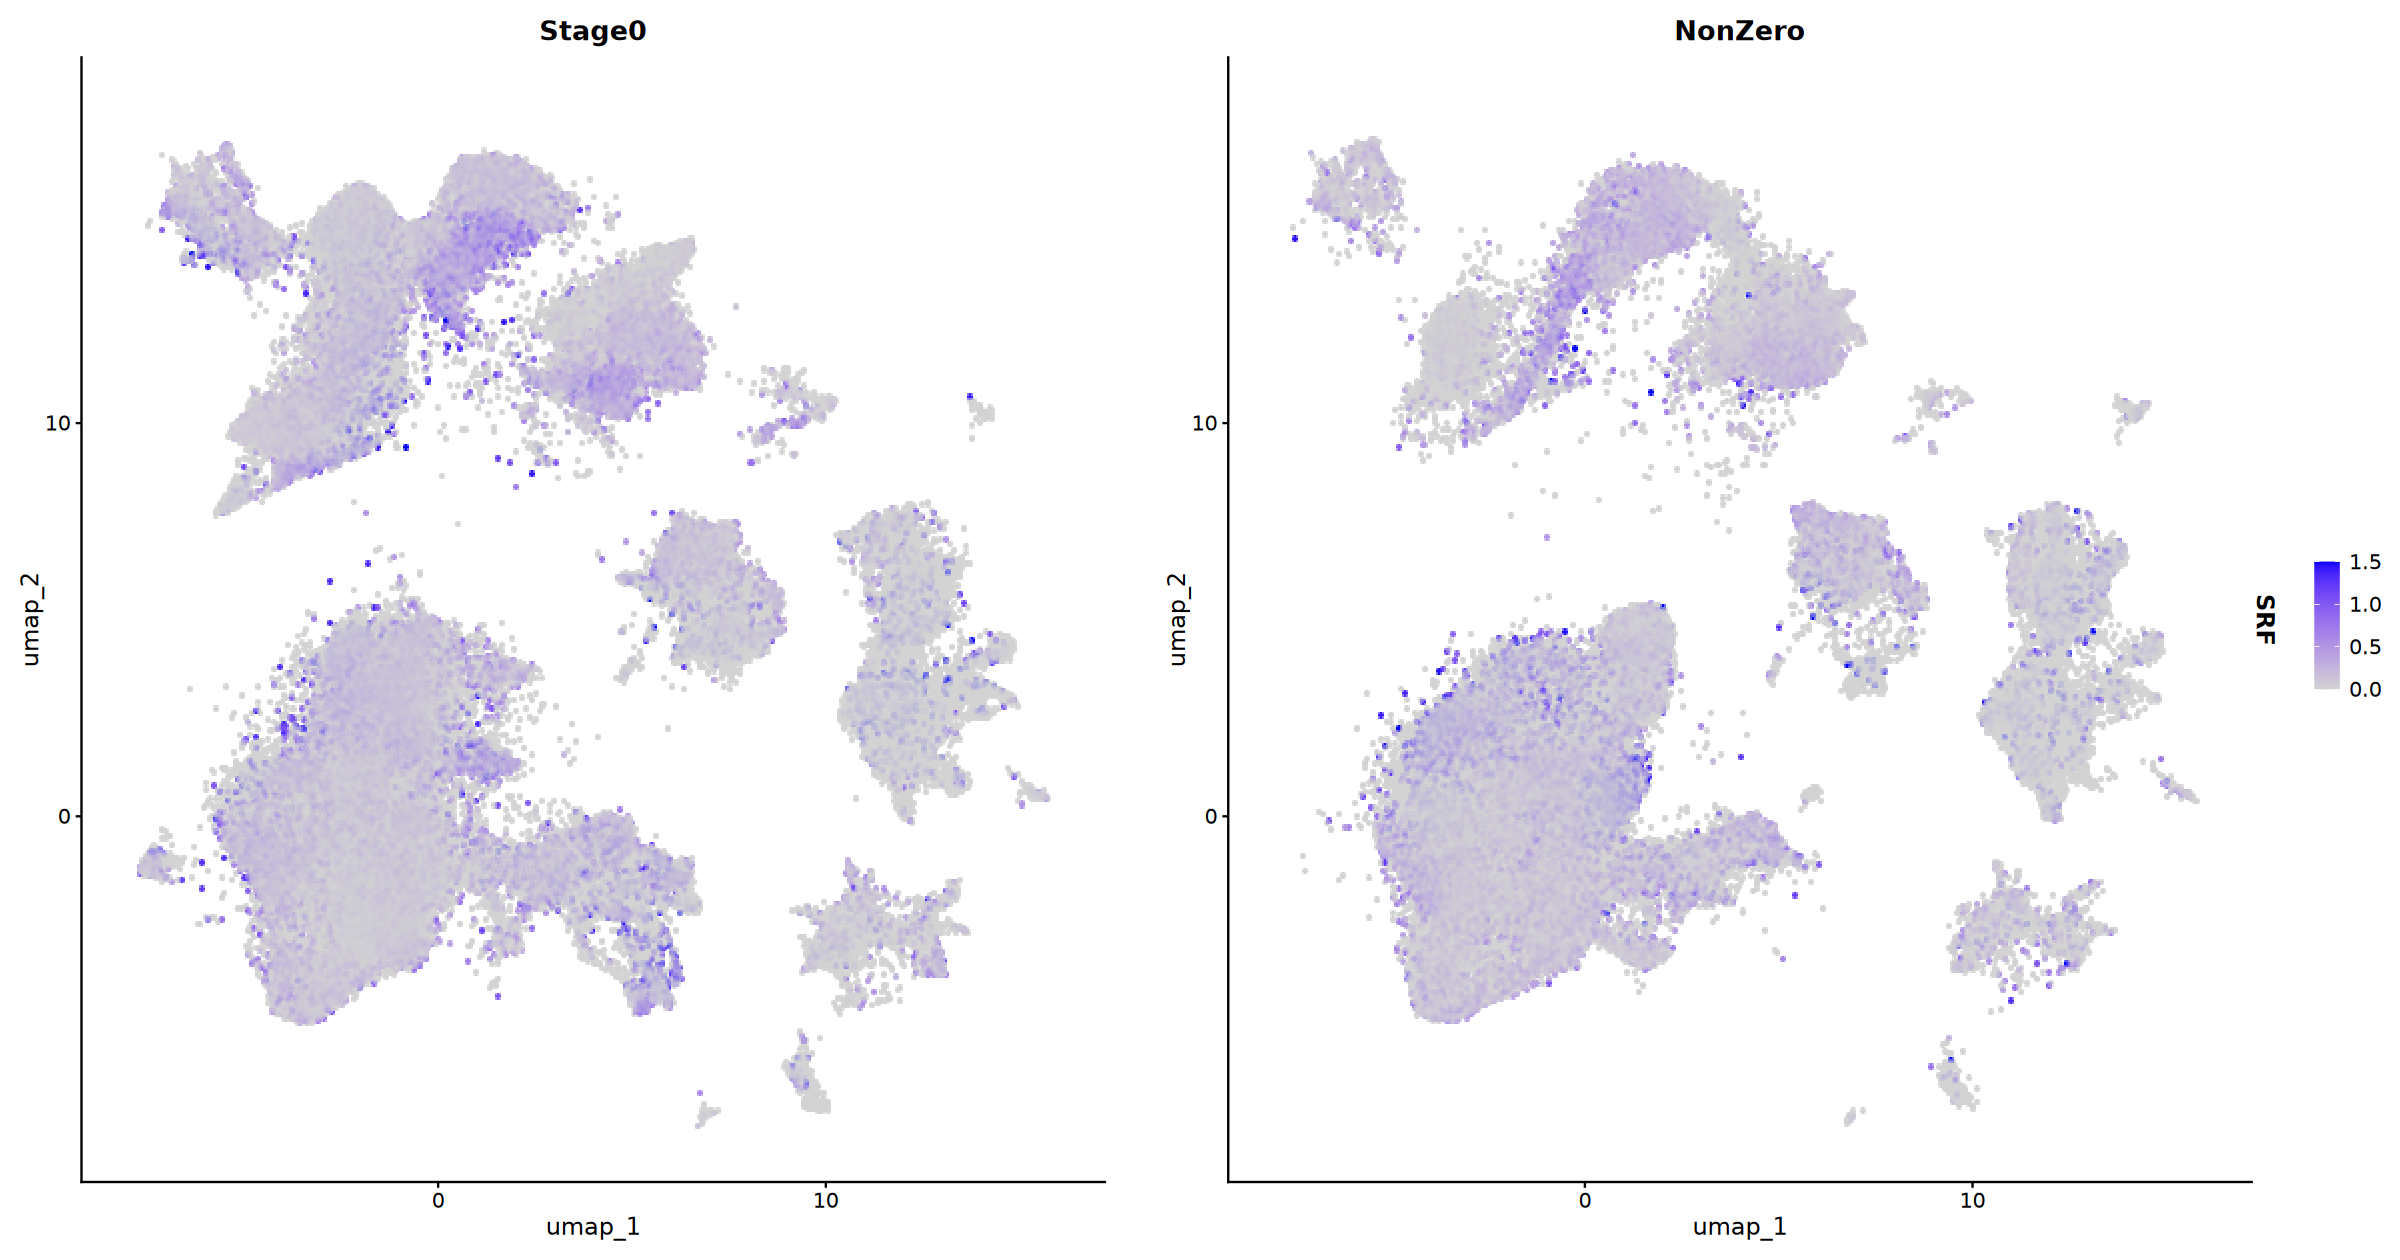

In [278]:
# Plot genes of interest

saved <- options(repr.plot.width = 20, repr.plot.height = 10.5) # Make the plots bigger from here on out, save old options
FeaturePlot(hecaNH,
            features = c('SRF'),
            split.by = "binary_pathology",
            label = FALSE, order = FALSE, min.cutoff = 0, max.cutoff = 1.5,
            pt.size = 2)  + theme(legend.position = "right")
options(saved) # restore old settings


Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



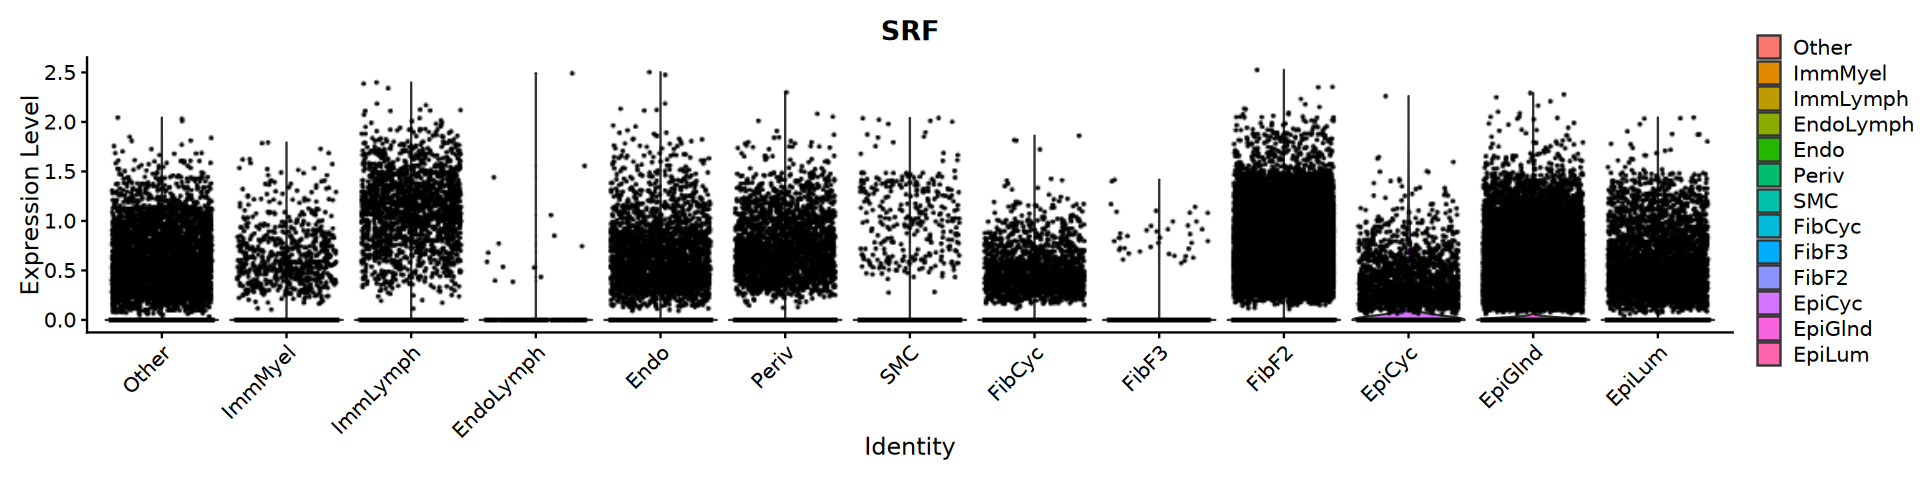

In [35]:
# SRF violin Plot by cell type

Idents(hecaNH) <- hecaNH$celltypeCollapsed

saved <- options(repr.plot.width = 16, repr.plot.height = 4) # Make the plots bigger from here on out, save old options
VlnPlot(hecaNH, features = c("SRF"), 
        group.by = "celltypeCollapsed",
        pt.size = 0.1)

options(saved) # restore old settings

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Warning message:
“Groups with fewer than two data points have been dropped.”


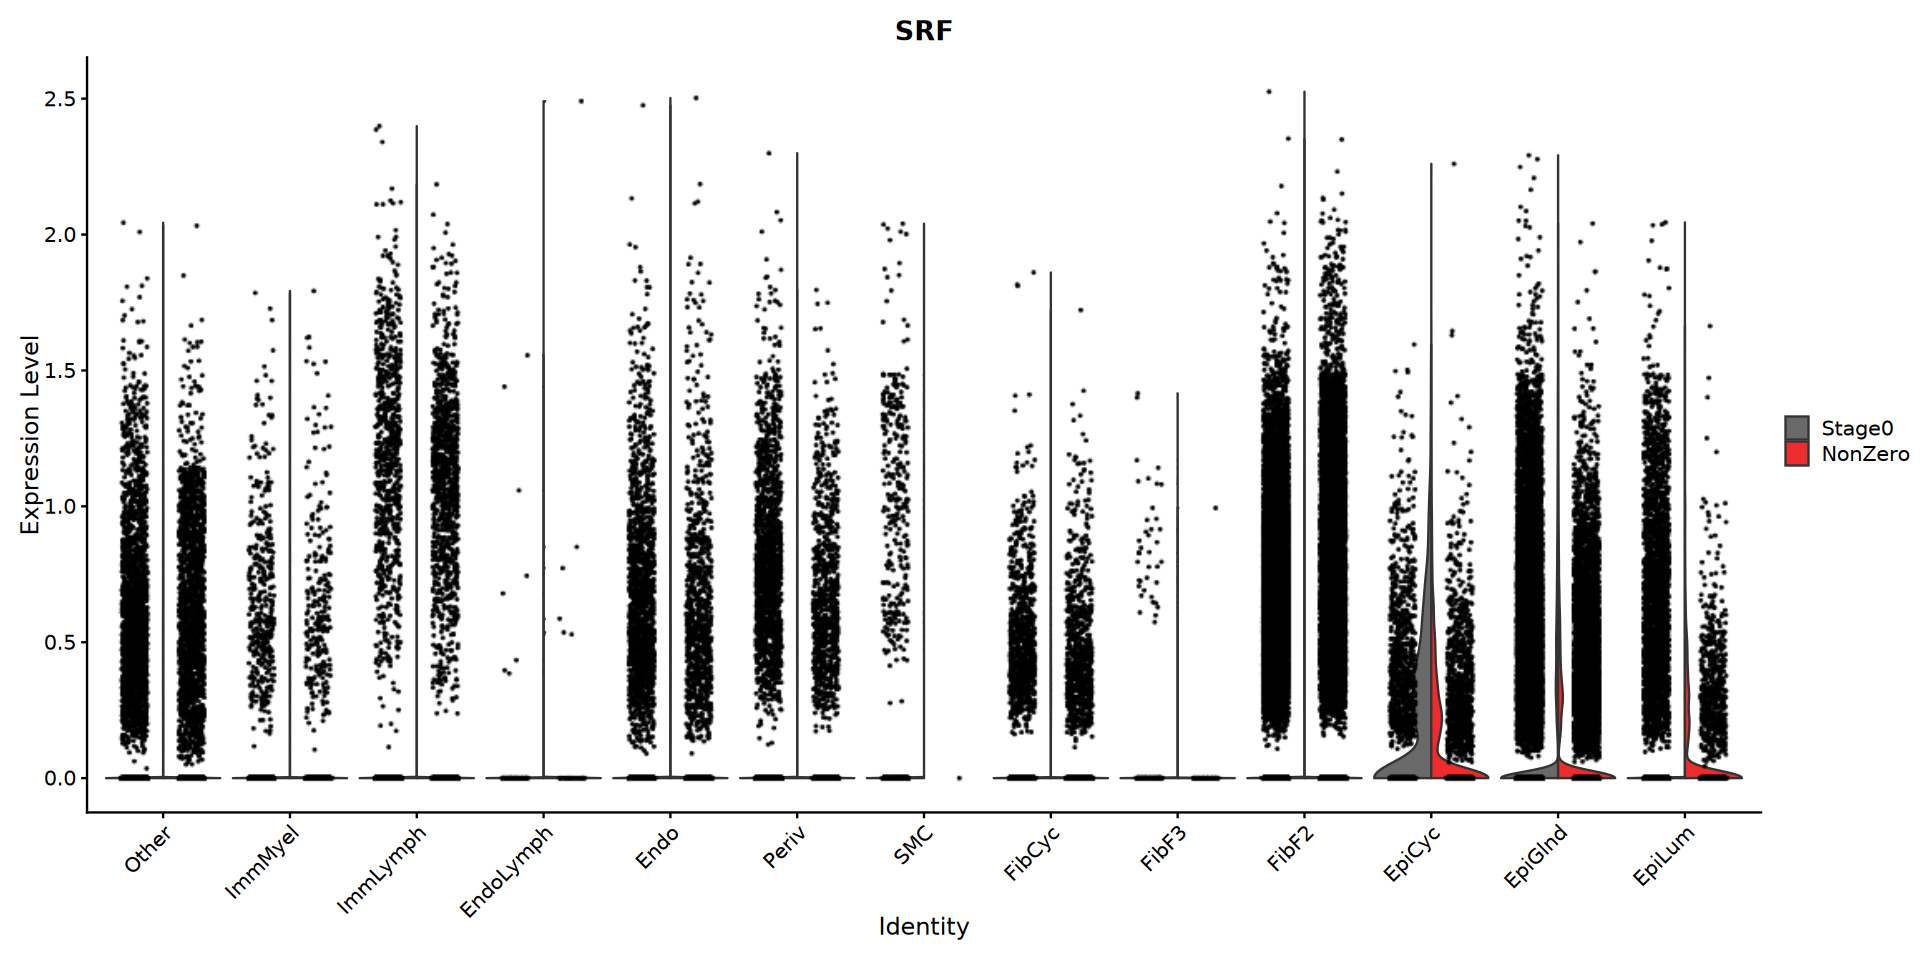

In [117]:
# SRF violin Plot by cell type/pathology

Idents(hecaNH) <- hecaNH$celltypeCollapsed

saved <- options(repr.plot.width = 16, repr.plot.height = 8) # Make the plots bigger from here on out, save old options
VlnPlot(hecaNH, features = c("SRF"), 
        group.by = "celltypeCollapsed",
        pt.size = 0.1,
        cols = c("dimgrey", "firebrick2"),
        split.plot = TRUE,
        split.by="binary_pathology",
)

options(saved) # restore old settings

Warning message:
“Groups with fewer than two data points have been dropped.”


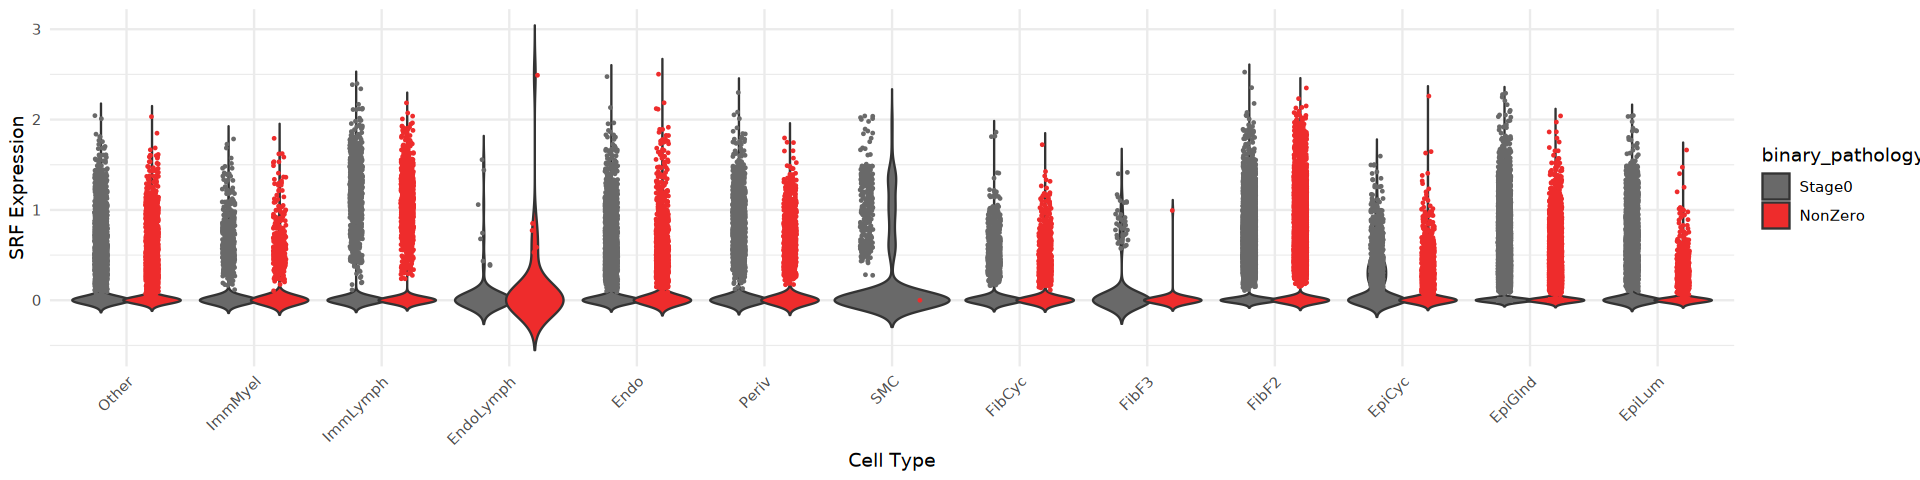

In [141]:
# Set the identities in the Seurat object
Idents(hecaNH) <- hecaNH$celltypeCollapsed

# Extract the data used to create the plot
data <- FetchData(hecaNH, vars = c("SRF", "celltypeCollapsed", "binary_pathology"))

# Create a new column for combined cell type and pathology
data$combined <- interaction(data$celltypeCollapsed, data$binary_pathology, sep = "_")

# Create the base plot with ggplot2 to control the point colors
p <- ggplot(data, aes(x = celltypeCollapsed, y = SRF, fill = binary_pathology)) +
  geom_violin(position = position_dodge(width = 0.8), scale = "width", trim = FALSE) +
  geom_point(aes(color = binary_pathology), position = position_jitterdodge(jitter.width = 0.2, dodge.width = 0.8), size = 0.3) +
  scale_fill_manual(values = c("dimgrey", "firebrick2")) +
  scale_color_manual(values = c("dimgrey", "firebrick2")) +
  theme_minimal() +
  labs(x = "Cell Type", y = "SRF Expression") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

# Print the plot
p


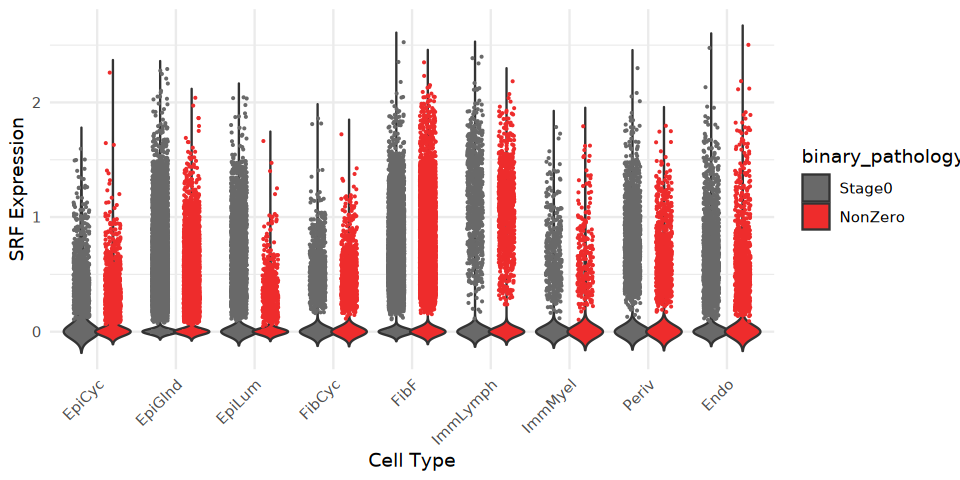

In [154]:
# Set the identities in the Seurat object
Idents(hecaNH) <- hecaNH$celltypeCollapsed

# Extract the data used to create the plot
data <- FetchData(hecaNH, vars = c("SRF", "celltypeCollapsed", "binary_pathology"))

# Convert celltypeCollapsed to character for easier manipulation
data$celltypeCollapsed <- as.character(data$celltypeCollapsed)

# Filter out the "SMC" and "EndoLymph" groups because they have fewer that 50 cells in the endometriosis datasets, also "other"
data <- data[!data$celltypeCollapsed %in% c("SMC", "EndoLymph", "Other"), ]

# Combine the "FibF3" and "FibF2" groups into a single group
data$celltypeCollapsed[data$celltypeCollapsed %in% c("FibF3", "FibF2")] <- "FibF"

# Convert celltypeCollapsed back to factor
data$celltypeCollapsed <- factor(data$celltypeCollapsed)

# Reorder the levels of celltypeCollapsed to move "Endo" to the end
levels_order <- c(setdiff(levels(data$celltypeCollapsed), "Endo"), "Endo")
data$celltypeCollapsed <- factor(data$celltypeCollapsed, levels = levels_order)

# Create the base plot with ggplot2 to control the point colors
p <- ggplot(data, aes(x = celltypeCollapsed, y = SRF, fill = binary_pathology)) +
  geom_violin(position = position_dodge(width = 0.8), scale = "width", trim = FALSE) +
  geom_jitter(aes(color = binary_pathology), position = position_jitterdodge(jitter.width = 0.4, dodge.width = 0.8), size = 0.1) +
  scale_fill_manual(values = c("dimgrey", "firebrick2")) +
  scale_color_manual(values = c("dimgrey", "firebrick2")) +
  theme_minimal() +
  labs(x = "Cell Type", y = "SRF Expression") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

# Print the plot
saved <- options(repr.plot.width = 8, repr.plot.height = 4) # Make the plots bigger from here on out, save old options
p
options(saved) # restore old settings

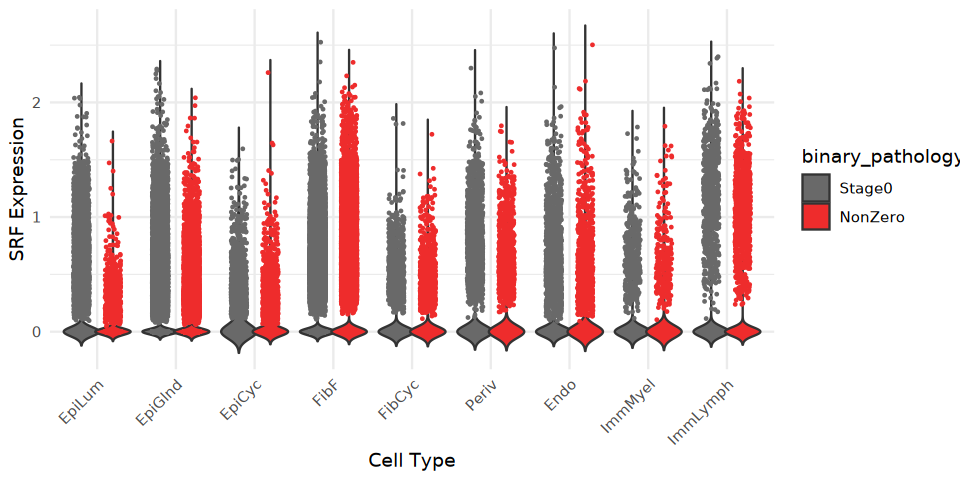

In [157]:
# Set the identities in the Seurat object
Idents(hecaNH) <- hecaNH$celltypeCollapsed

# Extract the data used to create the plot
data <- FetchData(hecaNH, vars = c("SRF", "celltypeCollapsed", "binary_pathology"))

# Convert celltypeCollapsed to character for easier manipulation
data$celltypeCollapsed <- as.character(data$celltypeCollapsed)

# Filter out the "SMC" and "EndoLymph" groups because they have fewer that 50 cells in the endometriosis datasets, also "other"
data <- data[!data$celltypeCollapsed %in% c("SMC", "EndoLymph", "other"), ]

# Combine the "FibF3" and "FibF2" groups into a single group
data$celltypeCollapsed[data$celltypeCollapsed %in% c("FibF3", "FibF2")] <- "FibF"

# Ensure that only desired groups are included
desired_order <- c("EpiLum", "EpiGlnd", "EpiCyc", "FibF", "FibCyc", "Periv", "Endo", "ImmMyel", "ImmLymph")
data <- data[data$celltypeCollapsed %in% desired_order, ]

# Convert celltypeCollapsed back to factor with the desired order
data$celltypeCollapsed <- factor(data$celltypeCollapsed, levels = desired_order)

# Create the base plot with ggplot2 to control the point colors
p <- ggplot(data, aes(x = celltypeCollapsed, y = SRF, fill = binary_pathology)) +
  geom_violin(position = position_dodge(width = 0.8), scale = "width", trim = FALSE) +
  geom_jitter(aes(color = binary_pathology), position = position_jitterdodge(jitter.width = 0.4, dodge.width = 0.8), size = 0.3) +
  scale_fill_manual(values = c("dimgrey", "firebrick2")) +
  scale_color_manual(values = c("dimgrey", "firebrick2")) +
  theme_minimal() +
  labs(x = "Cell Type", y = "SRF Expression") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

# Print the plot
saved <- options(repr.plot.width = 8, repr.plot.height = 4) # Make the plots bigger from here on out, save old options
p
options(saved) # restore old settings


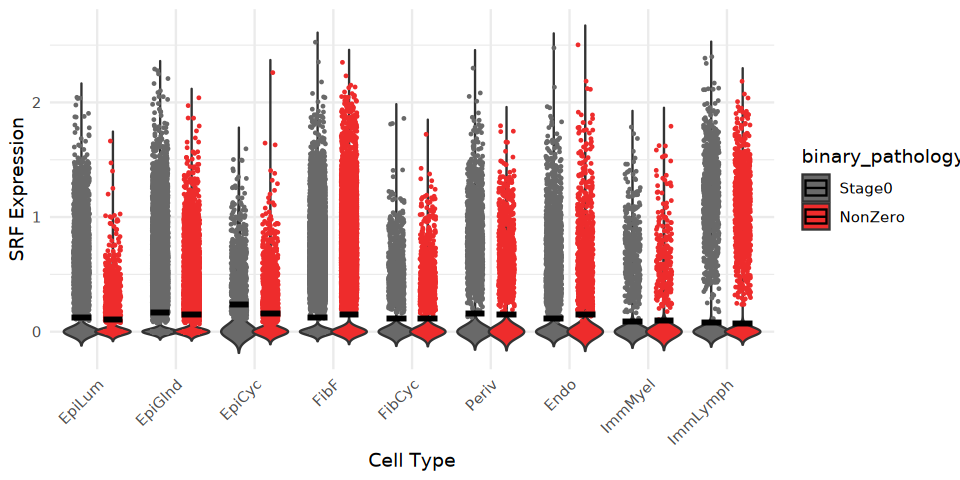

In [269]:
# Set the identities in the Seurat object
Idents(hecaNH) <- hecaNH$celltypeCollapsed

# Extract the data used to create the plot
data <- FetchData(hecaNH, vars = c("SRF", "celltypeCollapsed", "binary_pathology"))

# Convert celltypeCollapsed to character for easier manipulation
data$celltypeCollapsed <- as.character(data$celltypeCollapsed)

# Filter out the "SMC" and "EndoLymph" groups because they have fewer that 50 cells in the endometriosis datasets, also "other"
data <- data[!data$celltypeCollapsed %in% c("SMC", "EndoLymph", "other"), ]

# Combine the "FibF3" and "FibF2" groups into a single group
data$celltypeCollapsed[data$celltypeCollapsed %in% c("FibF3", "FibF2")] <- "FibF"

# Ensure that only desired groups are included
desired_order <- c("EpiLum", "EpiGlnd", "EpiCyc", "FibF", "FibCyc", "Periv", "Endo", "ImmMyel", "ImmLymph")
data <- data[data$celltypeCollapsed %in% desired_order, ]

# Convert celltypeCollapsed back to factor with the desired order
data$celltypeCollapsed <- factor(data$celltypeCollapsed, levels = desired_order)

# Create the base plot with ggplot2 to control the point colors
p <- ggplot(data, aes(x = celltypeCollapsed, y = SRF, fill = binary_pathology)) +
  geom_violin(position = position_dodge(width = 0.8), scale = "width", trim = FALSE) +
  geom_jitter(aes(color = binary_pathology), position = position_jitterdodge(jitter.width = 0.4, dodge.width = 0.8), size = 0.3) +
  stat_summary(fun = mean, geom = "crossbar", width = 0.5, position = position_dodge(width = 0.8), colour = "black") +
  scale_fill_manual(values = c("dimgrey", "firebrick2")) +
  scale_color_manual(values = c("dimgrey", "firebrick2")) +
  theme_minimal() +
  labs(x = "Cell Type", y = "SRF Expression") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

# Print the plot
saved <- options(repr.plot.width = 8, repr.plot.height = 4) # Make the plots bigger from here on out, save old options
p
options(saved) # restore old settings


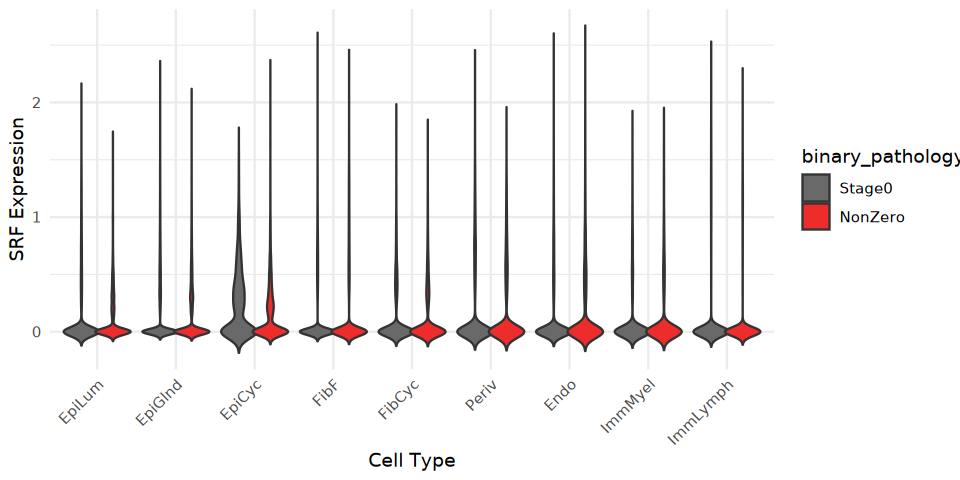

In [273]:
# Set the identities in the Seurat object
Idents(hecaNH) <- hecaNH$celltypeCollapsed

# Extract the data used to create the plot
data <- FetchData(hecaNH, vars = c("SRF", "celltypeCollapsed", "binary_pathology"))

# Convert celltypeCollapsed to character for easier manipulation
data$celltypeCollapsed <- as.character(data$celltypeCollapsed)

# Filter out the "SMC" and "EndoLymph" groups because they have fewer that 50 cells in the endometriosis datasets, also "other"
data <- data[!data$celltypeCollapsed %in% c("SMC", "EndoLymph", "other"), ]

# Combine the "FibF3" and "FibF2" groups into a single group
data$celltypeCollapsed[data$celltypeCollapsed %in% c("FibF3", "FibF2")] <- "FibF"

# Ensure that only desired groups are included
desired_order <- c("EpiLum", "EpiGlnd", "EpiCyc", "FibF", "FibCyc", "Periv", "Endo", "ImmMyel", "ImmLymph")
data <- data[data$celltypeCollapsed %in% desired_order, ]

# Convert celltypeCollapsed back to factor with the desired order
data$celltypeCollapsed <- factor(data$celltypeCollapsed, levels = desired_order)

# Create the base plot with ggplot2 to control the point colors
p <- ggplot(data, aes(x = celltypeCollapsed, y = SRF, fill = binary_pathology)) +
  geom_violin(position = position_dodge(width = 0.8), scale = "width", trim = FALSE) +
  scale_fill_manual(values = c("dimgrey", "firebrick2")) +
  scale_color_manual(values = c("dimgrey", "firebrick2")) +
  theme_minimal() +
  labs(x = "Cell Type", y = "SRF Expression") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

# Print the plot
saved <- options(repr.plot.width = 8, repr.plot.height = 4) # Make the plots bigger from here on out, save old options
p
options(saved) # restore old settings


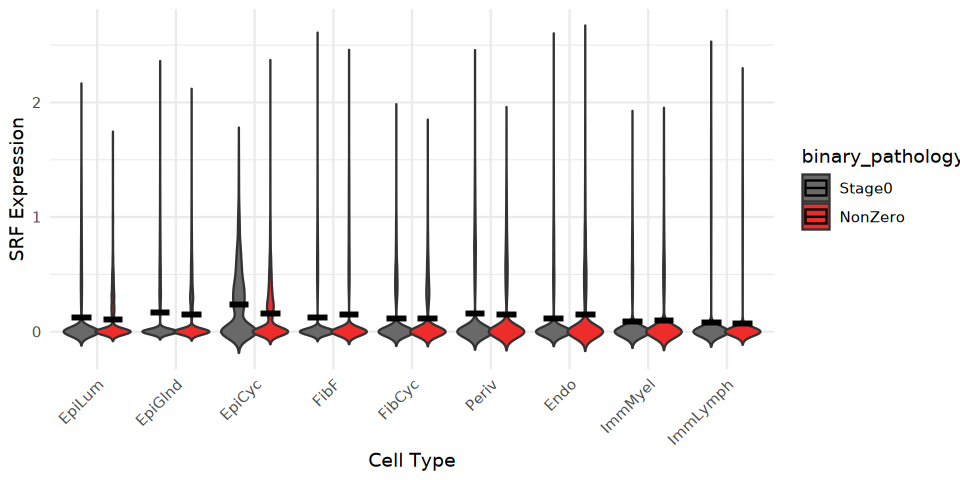

In [274]:
# Set the identities in the Seurat object
Idents(hecaNH) <- hecaNH$celltypeCollapsed

# Extract the data used to create the plot
data <- FetchData(hecaNH, vars = c("SRF", "celltypeCollapsed", "binary_pathology"))

# Convert celltypeCollapsed to character for easier manipulation
data$celltypeCollapsed <- as.character(data$celltypeCollapsed)

# Filter out the "SMC" and "EndoLymph" groups because they have fewer that 50 cells in the endometriosis datasets, also "other"
data <- data[!data$celltypeCollapsed %in% c("SMC", "EndoLymph", "other"), ]

# Combine the "FibF3" and "FibF2" groups into a single group
data$celltypeCollapsed[data$celltypeCollapsed %in% c("FibF3", "FibF2")] <- "FibF"

# Ensure that only desired groups are included
desired_order <- c("EpiLum", "EpiGlnd", "EpiCyc", "FibF", "FibCyc", "Periv", "Endo", "ImmMyel", "ImmLymph")
data <- data[data$celltypeCollapsed %in% desired_order, ]

# Convert celltypeCollapsed back to factor with the desired order
data$celltypeCollapsed <- factor(data$celltypeCollapsed, levels = desired_order)

# Create the base plot with ggplot2 to control the point colors
p <- ggplot(data, aes(x = celltypeCollapsed, y = SRF, fill = binary_pathology)) +
  geom_violin(position = position_dodge(width = 0.8), scale = "width", trim = FALSE) +
  stat_summary(fun = mean, geom = "crossbar", width = 0.5, position = position_dodge(width = 0.8), colour = "black") +
  scale_fill_manual(values = c("dimgrey", "firebrick2")) +
  scale_color_manual(values = c("dimgrey", "firebrick2")) +
  theme_minimal() +
  labs(x = "Cell Type", y = "SRF Expression") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

# Print the plot
saved <- options(repr.plot.width = 8, repr.plot.height = 4) # Make the plots bigger from here on out, save old options
p
options(saved) # restore old settings


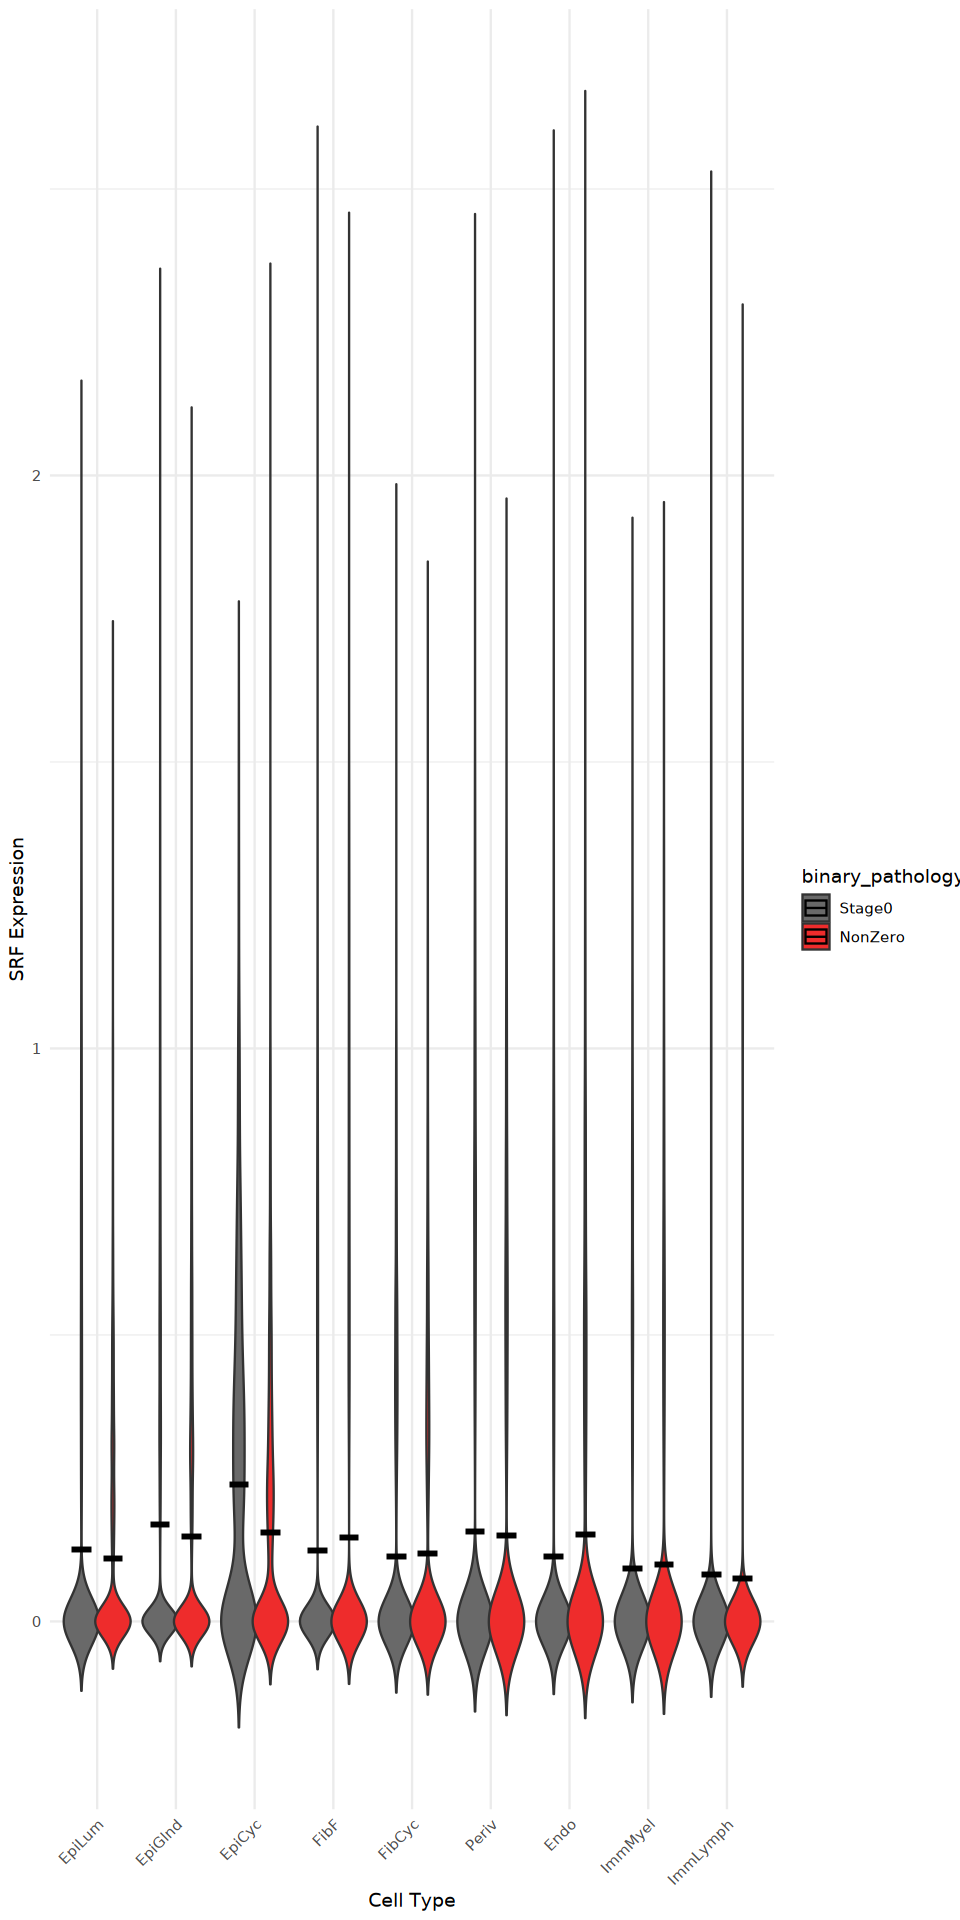

In [297]:
# Set the identities in the Seurat object
Idents(hecaNH) <- hecaNH$celltypeCollapsed

# Extract the data used to create the plot
data <- FetchData(hecaNH, vars = c("SRF", "celltypeCollapsed", "binary_pathology"))

# Convert celltypeCollapsed to character for easier manipulation
data$celltypeCollapsed <- as.character(data$celltypeCollapsed)

# Filter out the "SMC" and "EndoLymph" groups because they have fewer that 50 cells in the endometriosis datasets, also "other"
data <- data[!data$celltypeCollapsed %in% c("SMC", "EndoLymph", "other"), ]

# Combine the "FibF3" and "FibF2" groups into a single group
data$celltypeCollapsed[data$celltypeCollapsed %in% c("FibF3", "FibF2")] <- "FibF"

# Ensure that only desired groups are included
desired_order <- c("EpiLum", "EpiGlnd", "EpiCyc", "FibF", "FibCyc", "Periv", "Endo", "ImmMyel", "ImmLymph")
data <- data[data$celltypeCollapsed %in% desired_order, ]

# Convert celltypeCollapsed back to factor with the desired order
data$celltypeCollapsed <- factor(data$celltypeCollapsed, levels = desired_order)

# Create the base plot with ggplot2 to control the point colors
p <- ggplot(data, aes(x = celltypeCollapsed, y = SRF, fill = binary_pathology)) +
  geom_violin(position = position_dodge(width = 0.8), scale = "width", trim = FALSE) +
  stat_summary(fun = mean, geom = "crossbar", width = 0.5, position = position_dodge(width = 0.8), colour = "black") +
  scale_fill_manual(values = c("dimgrey", "firebrick2")) +
  scale_color_manual(values = c("dimgrey", "firebrick2")) +
  theme_minimal() +
  labs(x = "Cell Type", y = "SRF Expression") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

# Print the plot
saved <- options(repr.plot.width = 8, repr.plot.height = 16) # Make the plots bigger from here on out, save old options
p
options(saved) # restore old settings


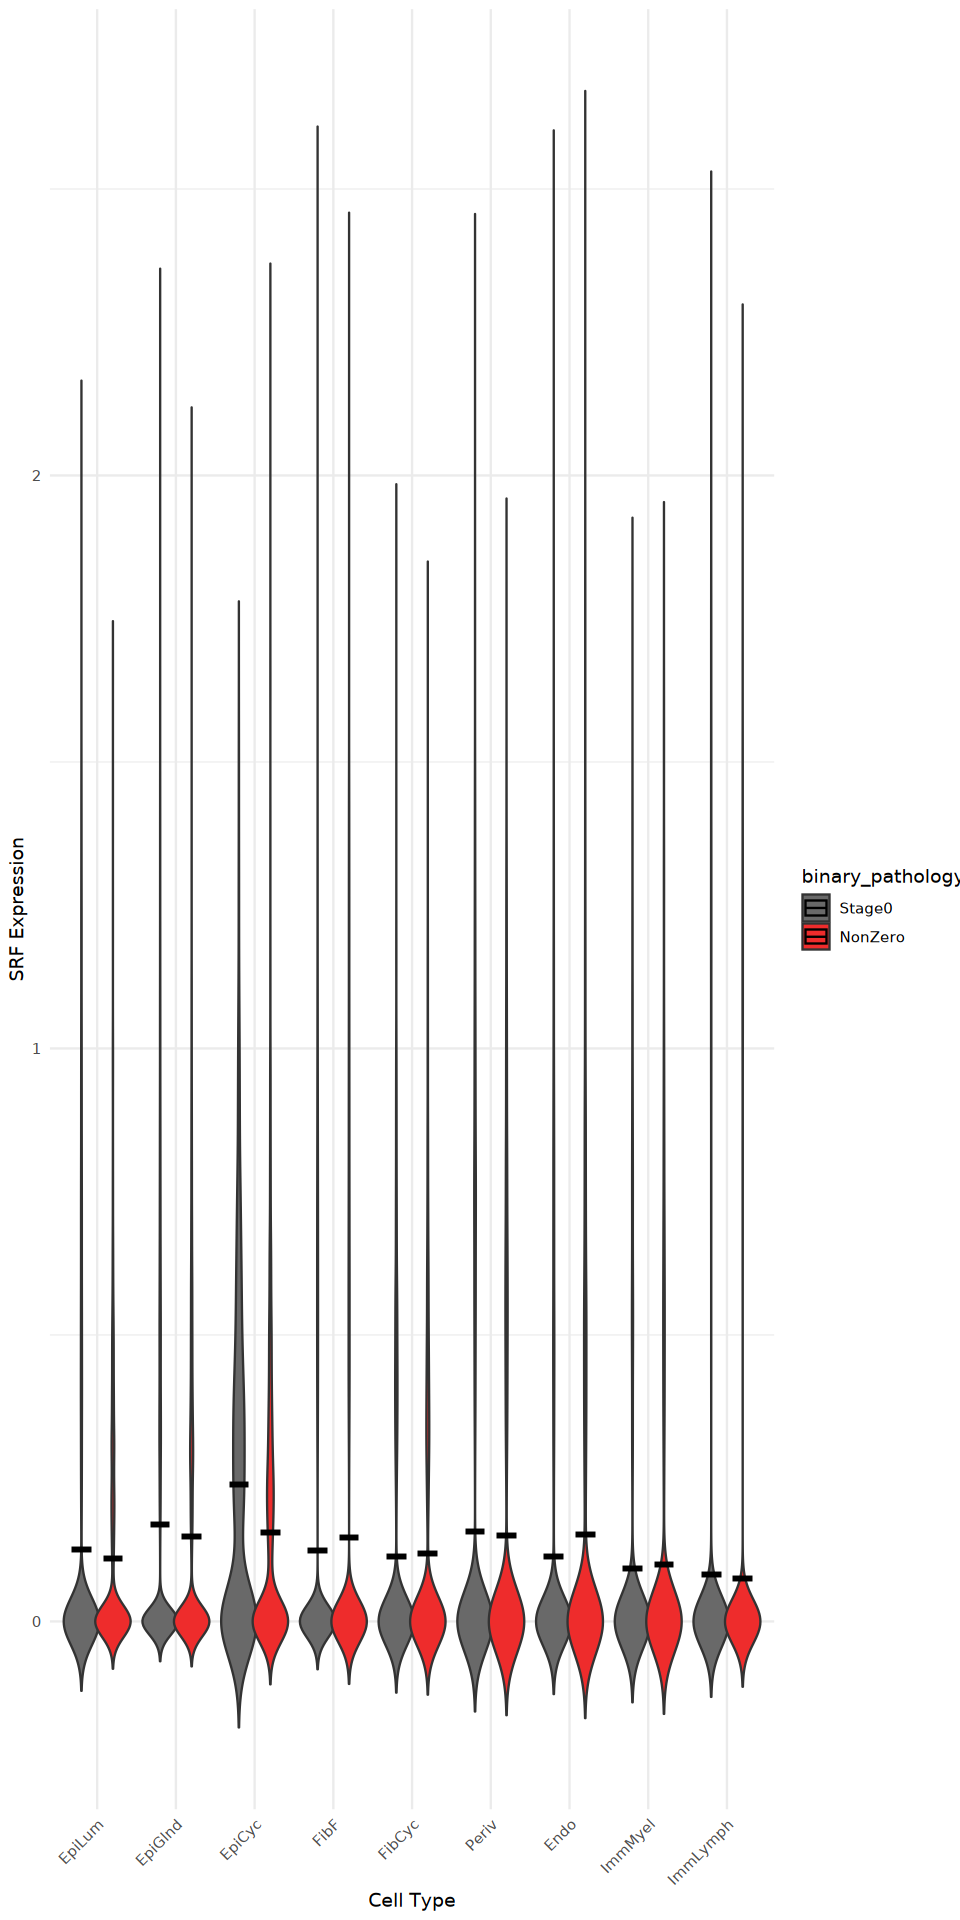

In [298]:
# Set the identities in the Seurat object
Idents(hecaNH) <- hecaNH$celltypeCollapsed

# Extract the data used to create the plot
data <- FetchData(hecaNH, vars = c("SRF", "celltypeCollapsed", "binary_pathology"))

# Convert celltypeCollapsed to character for easier manipulation
data$celltypeCollapsed <- as.character(data$celltypeCollapsed)

# Filter out the "SMC" and "EndoLymph" groups because they have fewer that 50 cells in the endometriosis datasets, also "other"
data <- data[!data$celltypeCollapsed %in% c("SMC", "EndoLymph", "other"), ]

# Combine the "FibF3" and "FibF2" groups into a single group
data$celltypeCollapsed[data$celltypeCollapsed %in% c("FibF3", "FibF2")] <- "FibF"

# Ensure that only desired groups are included
desired_order <- c("EpiLum", "EpiGlnd", "EpiCyc", "FibF", "FibCyc", "Periv", "Endo", "ImmMyel", "ImmLymph")
data <- data[data$celltypeCollapsed %in% desired_order, ]

# Convert celltypeCollapsed back to factor with the desired order
data$celltypeCollapsed <- factor(data$celltypeCollapsed, levels = desired_order)

# Create a custom labeling function for y-axis
custom_y_labels <- function(breaks) {
  labels <- ifelse(breaks %% 1 == 0, as.character(breaks), as.character(breaks))
  return(labels)
}

# Create the base plot with ggplot2 to control the point colors
p <- ggplot(data, aes(x = celltypeCollapsed, y = SRF, fill = binary_pathology)) +
  geom_violin(position = position_dodge(width = 0.8), scale = "width", trim = FALSE) +
  stat_summary(fun = mean, geom = "crossbar", width = 0.5, position = position_dodge(width = 0.8), colour = "black") +
  scale_fill_manual(values = c("dimgrey", "firebrick2")) +
  scale_color_manual(values = c("dimgrey", "firebrick2")) +
  scale_y_continuous(
    breaks = seq(floor(min(data$SRF)), ceiling(max(data$SRF)), by = 1),  # Define major breaks
    minor_breaks = seq(floor(min(data$SRF)), ceiling(max(data$SRF)), by = 0.5),  # Define minor breaks
    labels = custom_y_labels
  ) +
  theme_minimal() +
  labs(x = "Cell Type", y = "SRF Expression") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

# Print the plot
saved <- options(repr.plot.width = 8, repr.plot.height = 16) # Make the plots bigger from here on out, save old options
p
options(saved) # restore old settings


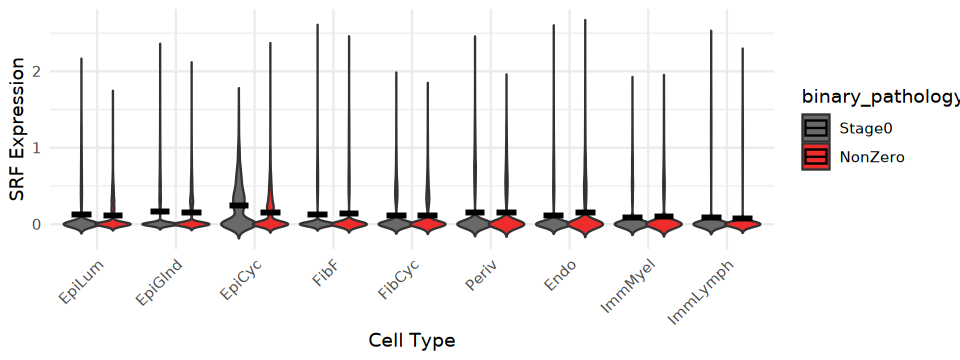

In [304]:
# Set the identities in the Seurat object
Idents(hecaNH) <- hecaNH$celltypeCollapsed

# Extract the data used to create the plot
data <- FetchData(hecaNH, vars = c("SRF", "celltypeCollapsed", "binary_pathology"))

# Convert celltypeCollapsed to character for easier manipulation
data$celltypeCollapsed <- as.character(data$celltypeCollapsed)

# Filter out the "SMC" and "EndoLymph" groups because they have fewer that 50 cells in the endometriosis datasets, also "other"
data <- data[!data$celltypeCollapsed %in% c("SMC", "EndoLymph", "other"), ]

# Combine the "FibF3" and "FibF2" groups into a single group
data$celltypeCollapsed[data$celltypeCollapsed %in% c("FibF3", "FibF2")] <- "FibF"

# Ensure that only desired groups are included
desired_order <- c("EpiLum", "EpiGlnd", "EpiCyc", "FibF", "FibCyc", "Periv", "Endo", "ImmMyel", "ImmLymph")
data <- data[data$celltypeCollapsed %in% desired_order, ]

# Convert celltypeCollapsed back to factor with the desired order
data$celltypeCollapsed <- factor(data$celltypeCollapsed, levels = desired_order)

# Create a custom labeling function for y-axis
custom_y_labels <- function(breaks) {
  labels <- ifelse(breaks %% 1 == 0, as.character(breaks), as.character(breaks))
  return(labels)
}

# Create the base plot with ggplot2 to control the point colors
p <- ggplot(data, aes(x = celltypeCollapsed, y = SRF, fill = binary_pathology)) +
  geom_violin(position = position_dodge(width = 0.8), scale = "width", trim = FALSE) +
  stat_summary(fun = mean, geom = "crossbar", width = 0.5, position = position_dodge(width = 0.8), colour = "black") +
  scale_fill_manual(values = c("dimgrey", "firebrick2")) +
  scale_color_manual(values = c("dimgrey", "firebrick2")) +
  scale_y_continuous(
    breaks = seq(floor(min(data$SRF)), ceiling(max(data$SRF)), by = 1),  # Define major breaks
    minor_breaks = seq(floor(min(data$SRF)), ceiling(max(data$SRF)), by = 0.5),  # Define minor breaks
    labels = custom_y_labels
  ) +
  theme_minimal() +
  labs(x = "Cell Type", y = "SRF Expression") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

# Print the plot
saved <- options(repr.plot.width = 8, repr.plot.height = 3) # Make the plots bigger from here on out, save old options
p
options(saved) # restore old settings


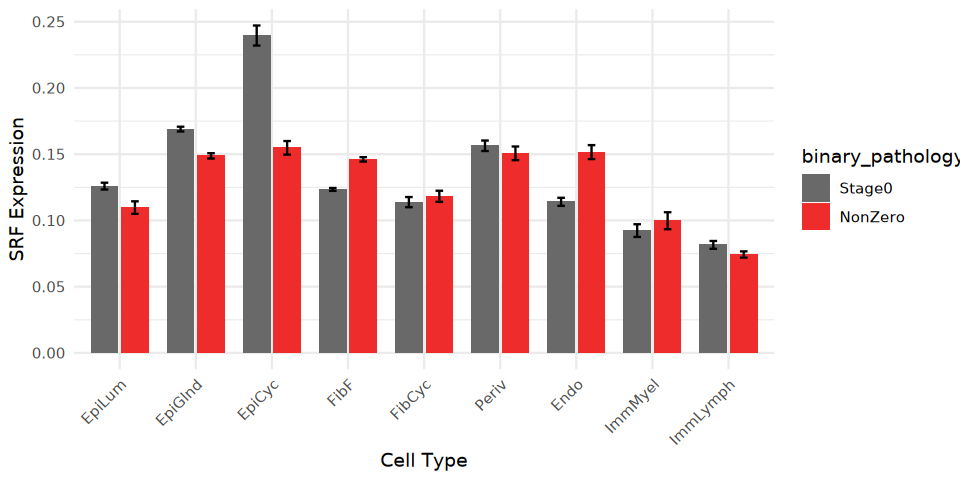

In [286]:
# Set the identities in the Seurat object
Idents(hecaNH) <- hecaNH$celltypeCollapsed

# Extract the data used to create the plot
data <- FetchData(hecaNH, vars = c("SRF", "celltypeCollapsed", "binary_pathology"))

# Convert celltypeCollapsed to character for easier manipulation
data$celltypeCollapsed <- as.character(data$celltypeCollapsed)

# Filter out the "SMC" and "EndoLymph" groups because they have fewer that 50 cells in the endometriosis datasets, also "other"
data <- data[!data$celltypeCollapsed %in% c("SMC", "EndoLymph", "other"), ]

# Combine the "FibF3" and "FibF2" groups into a single group
data$celltypeCollapsed[data$celltypeCollapsed %in% c("FibF3", "FibF2")] <- "FibF"

# Ensure that only desired groups are included
desired_order <- c("EpiLum", "EpiGlnd", "EpiCyc", "FibF", "FibCyc", "Periv", "Endo", "ImmMyel", "ImmLymph")
data <- data[data$celltypeCollapsed %in% desired_order, ]

# Convert celltypeCollapsed back to factor with the desired order
data$celltypeCollapsed <- factor(data$celltypeCollapsed, levels = desired_order)

# Create the base plot with ggplot2 to control the point colors
p <- ggplot(data, aes(x = celltypeCollapsed, y = SRF, fill = binary_pathology)) +
  stat_summary(
    fun = mean,
    geom = "bar",
    position = position_dodge(width = 0.8),
    width = 0.7
  ) +
  stat_summary(
    fun.data = mean_se,
    geom = "errorbar",
    width = 0.2,
    position = position_dodge(width = 0.8),
    colour = "black"
  ) +
  scale_fill_manual(values = c("dimgrey", "firebrick2")) +
  scale_color_manual(values = c("dimgrey", "firebrick2")) +
  theme_minimal() +
  labs(x = "Cell Type", y = "SRF Expression") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

# Print the plot
saved <- options(repr.plot.width = 8, repr.plot.height = 4) # Make the plots bigger from here on out, save old options
p
options(saved) # restore old settings


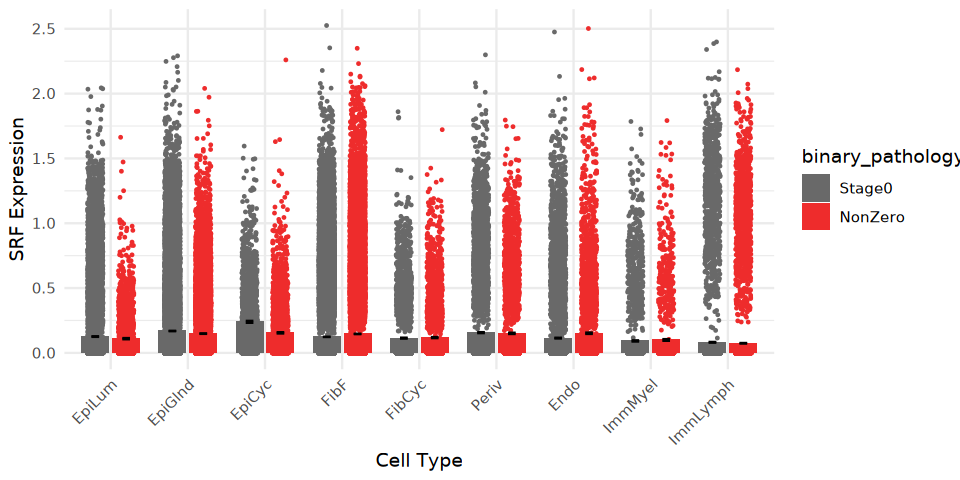

In [287]:
# Set the identities in the Seurat object
Idents(hecaNH) <- hecaNH$celltypeCollapsed

# Extract the data used to create the plot
data <- FetchData(hecaNH, vars = c("SRF", "celltypeCollapsed", "binary_pathology"))

# Convert celltypeCollapsed to character for easier manipulation
data$celltypeCollapsed <- as.character(data$celltypeCollapsed)

# Filter out the "SMC" and "EndoLymph" groups because they have fewer that 50 cells in the endometriosis datasets, also "other"
data <- data[!data$celltypeCollapsed %in% c("SMC", "EndoLymph", "other"), ]

# Combine the "FibF3" and "FibF2" groups into a single group
data$celltypeCollapsed[data$celltypeCollapsed %in% c("FibF3", "FibF2")] <- "FibF"

# Ensure that only desired groups are included
desired_order <- c("EpiLum", "EpiGlnd", "EpiCyc", "FibF", "FibCyc", "Periv", "Endo", "ImmMyel", "ImmLymph")
data <- data[data$celltypeCollapsed %in% desired_order, ]

# Convert celltypeCollapsed back to factor with the desired order
data$celltypeCollapsed <- factor(data$celltypeCollapsed, levels = desired_order)

# Create the base plot with ggplot2 to control the point colors
p <- ggplot(data, aes(x = celltypeCollapsed, y = SRF, fill = binary_pathology)) +
  stat_summary(
    fun = mean,
    geom = "bar",
    position = position_dodge(width = 0.8),
    width = 0.7
  ) +
  geom_jitter(aes(color = binary_pathology), position = position_jitterdodge(jitter.width = 0.4, dodge.width = 0.8), size = 0.3) +
  stat_summary(
    fun.data = mean_se,
    geom = "errorbar",
    width = 0.2,
    position = position_dodge(width = 0.8),
    colour = "black"
  ) +
  scale_fill_manual(values = c("dimgrey", "firebrick2")) +
  scale_color_manual(values = c("dimgrey", "firebrick2")) +
  theme_minimal() +
  labs(x = "Cell Type", y = "SRF Expression") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

# Print the plot
saved <- options(repr.plot.width = 8, repr.plot.height = 4) # Make the plots bigger from here on out, save old options
p
options(saved) # restore old settings


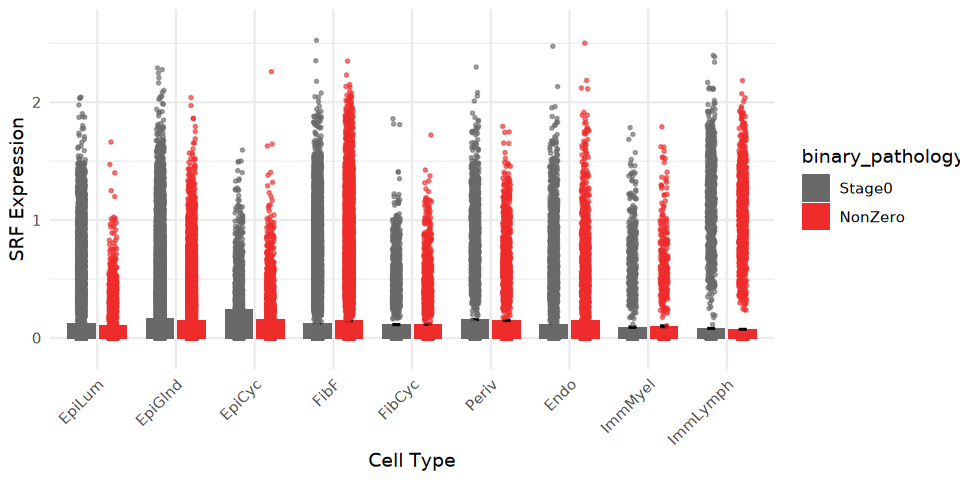

In [289]:
# Set the identities in the Seurat object
Idents(hecaNH) <- hecaNH$celltypeCollapsed

# Extract the data used to create the plot
data <- FetchData(hecaNH, vars = c("SRF", "celltypeCollapsed", "binary_pathology"))

# Convert celltypeCollapsed to character for easier manipulation
data$celltypeCollapsed <- as.character(data$celltypeCollapsed)

# Filter out the "SMC" and "EndoLymph" groups because they have fewer that 50 cells in the endometriosis datasets, also "other"
data <- data[!data$celltypeCollapsed %in% c("SMC", "EndoLymph", "other"), ]

# Combine the "FibF3" and "FibF2" groups into a single group
data$celltypeCollapsed[data$celltypeCollapsed %in% c("FibF3", "FibF2")] <- "FibF"

# Ensure that only desired groups are included
desired_order <- c("EpiLum", "EpiGlnd", "EpiCyc", "FibF", "FibCyc", "Periv", "Endo", "ImmMyel", "ImmLymph")
data <- data[data$celltypeCollapsed %in% desired_order, ]

# Convert celltypeCollapsed back to factor with the desired order
data$celltypeCollapsed <- factor(data$celltypeCollapsed, levels = desired_order)

# Determine y-axis limits based on the data, with some padding
y_max <- max(data$SRF, na.rm = TRUE)
y_min <- min(data$SRF, na.rm = TRUE)
padding <- 0.05 * (y_max - y_min)

# Create the base plot with ggplot2 to control the point colors
p <- ggplot(data, aes(x = celltypeCollapsed, y = SRF, fill = binary_pathology)) +
  stat_summary(
    fun = mean,
    geom = "bar",
    position = position_dodge(width = 0.8),
    width = 0.7
  ) +
  stat_summary(
    fun.data = mean_se,
    geom = "errorbar",
    width = 0.2,
    position = position_dodge(width = 0.8),
    colour = "black"
  ) +
  geom_jitter(
    aes(color = binary_pathology),
    position = position_jitterdodge(jitter.width = 0.2, dodge.width = 0.8),
    size = 0.5,
    alpha = 0.6
  ) +
  scale_fill_manual(values = c("dimgrey", "firebrick2")) +
  scale_color_manual(values = c("dimgrey", "firebrick2")) +
  theme_minimal() +
  labs(x = "Cell Type", y = "SRF Expression") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  coord_cartesian(ylim = c(y_min - padding, y_max + padding))

# Print the plot
saved <- options(repr.plot.width = 8, repr.plot.height = 4) # Make the plots bigger from here on out, save old options
p
options(saved) # restore old settings


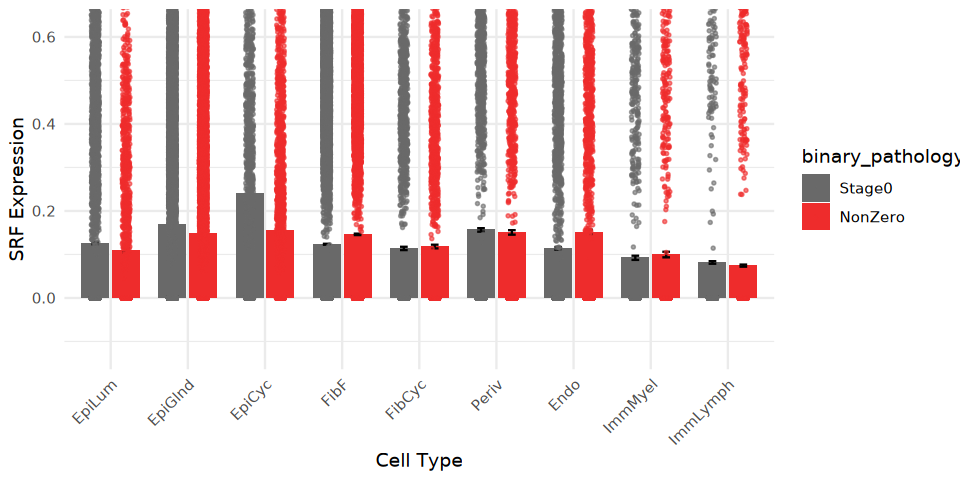

In [290]:
# Set the identities in the Seurat object
Idents(hecaNH) <- hecaNH$celltypeCollapsed

# Extract the data used to create the plot
data <- FetchData(hecaNH, vars = c("SRF", "celltypeCollapsed", "binary_pathology"))

# Convert celltypeCollapsed to character for easier manipulation
data$celltypeCollapsed <- as.character(data$celltypeCollapsed)

# Filter out the "SMC" and "EndoLymph" groups because they have fewer that 50 cells in the endometriosis datasets, also "other"
data <- data[!data$celltypeCollapsed %in% c("SMC", "EndoLymph", "other"), ]

# Combine the "FibF3" and "FibF2" groups into a single group
data$celltypeCollapsed[data$celltypeCollapsed %in% c("FibF3", "FibF2")] <- "FibF"

# Ensure that only desired groups are included
desired_order <- c("EpiLum", "EpiGlnd", "EpiCyc", "FibF", "FibCyc", "Periv", "Endo", "ImmMyel", "ImmLymph")
data <- data[data$celltypeCollapsed %in% desired_order, ]

# Convert celltypeCollapsed back to factor with the desired order
data$celltypeCollapsed <- factor(data$celltypeCollapsed, levels = desired_order)

# Determine y-axis limits based on the data, with some padding
y_max <- max(data$SRF, na.rm = TRUE)
y_min <- min(data$SRF, na.rm = TRUE)
padding <- 0.05 * (y_max - y_min)

# Create the base plot with ggplot2 to control the point colors
p <- ggplot(data, aes(x = celltypeCollapsed, y = SRF, fill = binary_pathology)) +
  stat_summary(
    fun = mean,
    geom = "bar",
    position = position_dodge(width = 0.8),
    width = 0.7
  ) +
  stat_summary(
    fun.data = mean_se,
    geom = "errorbar",
    width = 0.2,
    position = position_dodge(width = 0.8),
    colour = "black"
  ) +
  geom_jitter(
    aes(color = binary_pathology),
    position = position_jitterdodge(jitter.width = 0.2, dodge.width = 0.8),
    size = 0.5,
    alpha = 0.6
  ) +
  scale_fill_manual(values = c("dimgrey", "firebrick2")) +
  scale_color_manual(values = c("dimgrey", "firebrick2")) +
  theme_minimal() +
  labs(x = "Cell Type", y = "SRF Expression") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  coord_cartesian(ylim = c(y_min - padding, y_min + padding + 0.5))  # Adjust y-axis limits to zoom in

# Print the plot
saved <- options(repr.plot.width = 8, repr.plot.height = 4) # Make the plots bigger from here on out, save old options
p
options(saved) # restore old settings


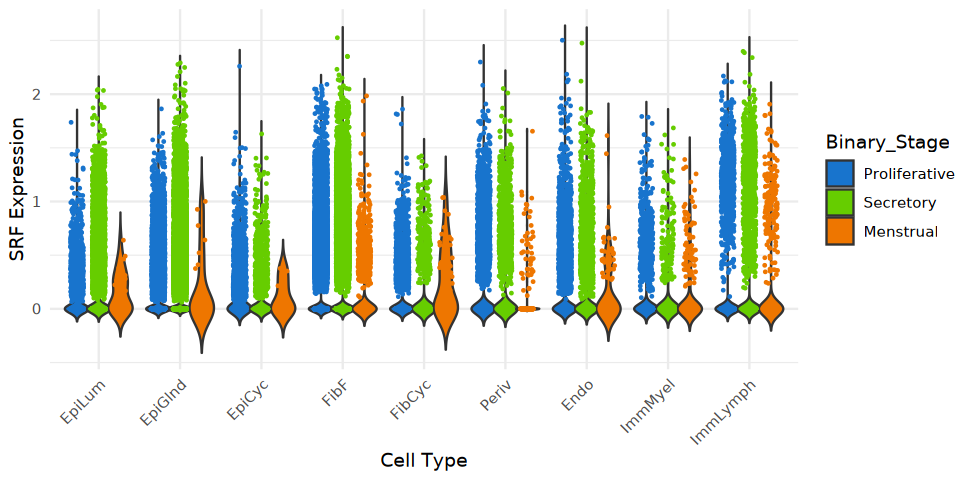

In [270]:
# Set the identities in the Seurat object
Idents(hecaNH) <- hecaNH$celltypeCollapsed

# Extract the data used to create the plot
data <- FetchData(hecaNH, vars = c("SRF", "celltypeCollapsed", "Binary_Stage"))

# Convert celltypeCollapsed to character for easier manipulation
data$celltypeCollapsed <- as.character(data$celltypeCollapsed)

# Filter out the "SMC" and "EndoLymph" groups because they have fewer that 50 cells in the endometriosis datasets, also "other"
data <- data[!data$celltypeCollapsed %in% c("SMC", "EndoLymph", "other"), ]

# Combine the "FibF3" and "FibF2" groups into a single group
data$celltypeCollapsed[data$celltypeCollapsed %in% c("FibF3", "FibF2")] <- "FibF"

# Ensure that only desired groups are included
desired_order <- c("EpiLum", "EpiGlnd", "EpiCyc", "FibF", "FibCyc", "Periv", "Endo", "ImmMyel", "ImmLymph")
data <- data[data$celltypeCollapsed %in% desired_order, ]

# Convert celltypeCollapsed back to factor with the desired order
data$celltypeCollapsed <- factor(data$celltypeCollapsed, levels = desired_order)

# Convert Binary_Stage to character for easier manipulation
data$Binary_Stage <- as.character(data$Binary_Stage)

# Ensure that desired groups are included in desired order
desired_order <- c("Proliferative", "Secretory", "Menstrual")
data <- data[data$Binary_Stage %in% desired_order, ]

# Convert celltypeCollapsed back to factor with the desired order
data$Binary_Stage <- factor(data$Binary_Stage, levels = desired_order)

# Create the base plot with ggplot2 to control the point colors
p <- ggplot(data, aes(x = celltypeCollapsed, y = SRF, fill = Binary_Stage)) +
  geom_violin(position = position_dodge(width = 0.8), scale = "width", trim = FALSE) +
  geom_jitter(aes(color = Binary_Stage), position = position_jitterdodge(jitter.width = 0.4, dodge.width = 0.8), size = 0.3) +
  scale_fill_manual(values = c("dodgerblue3", "chartreuse3", "darkorange2")) +
  scale_color_manual(values = c("dodgerblue3", "chartreuse3", "darkorange2")) +
  theme_minimal() +
  labs(x = "Cell Type", y = "SRF Expression") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

# Print the plot
saved <- options(repr.plot.width = 8, repr.plot.height = 4) # Make the plots bigger from here on out, save old options
p
options(saved) # restore old settings


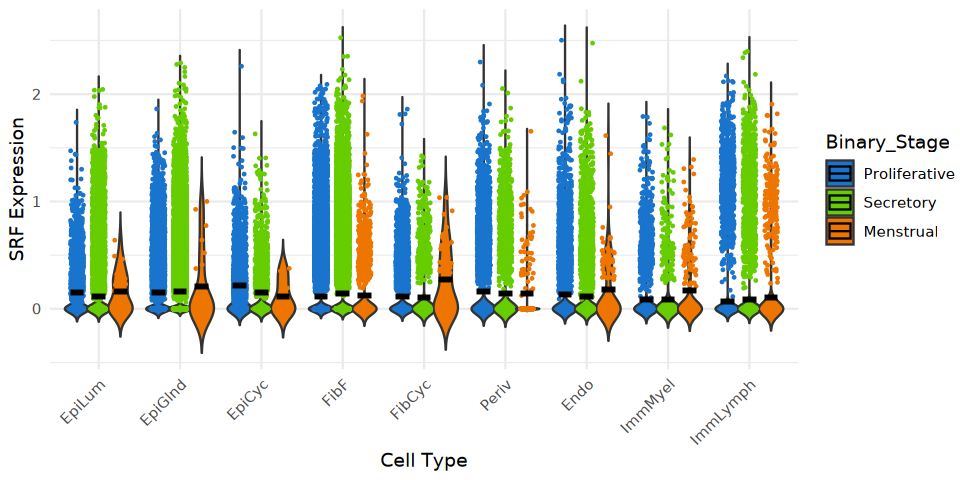

In [268]:
# Set the identities in the Seurat object
Idents(hecaNH) <- hecaNH$celltypeCollapsed

# Extract the data used to create the plot
data <- FetchData(hecaNH, vars = c("SRF", "celltypeCollapsed", "Binary_Stage"))

# Convert celltypeCollapsed to character for easier manipulation
data$celltypeCollapsed <- as.character(data$celltypeCollapsed)

# Filter out the "SMC" and "EndoLymph" groups because they have fewer that 50 cells in the endometriosis datasets, also "other"
data <- data[!data$celltypeCollapsed %in% c("SMC", "EndoLymph", "other"), ]

# Combine the "FibF3" and "FibF2" groups into a single group
data$celltypeCollapsed[data$celltypeCollapsed %in% c("FibF3", "FibF2")] <- "FibF"

# Ensure that only desired groups are included
desired_order <- c("EpiLum", "EpiGlnd", "EpiCyc", "FibF", "FibCyc", "Periv", "Endo", "ImmMyel", "ImmLymph")
data <- data[data$celltypeCollapsed %in% desired_order, ]

# Convert celltypeCollapsed back to factor with the desired order
data$celltypeCollapsed <- factor(data$celltypeCollapsed, levels = desired_order)

# Convert Binary_Stage to character for easier manipulation
data$Binary_Stage <- as.character(data$Binary_Stage)

# Ensure that desired groups are included in desired order
desired_order <- c("Proliferative", "Secretory", "Menstrual")
data <- data[data$Binary_Stage %in% desired_order, ]

# Convert celltypeCollapsed back to factor with the desired order
data$Binary_Stage <- factor(data$Binary_Stage, levels = desired_order)

# Create the base plot with ggplot2 to control the point colors
p <- ggplot(data, aes(x = celltypeCollapsed, y = SRF, fill = Binary_Stage)) +
  geom_violin(position = position_dodge(width = 0.8), scale = "width", trim = FALSE) +
  geom_jitter(aes(color = Binary_Stage), position = position_jitterdodge(jitter.width = 0.4, dodge.width = 0.8), size = 0.3) +
  stat_summary(fun = mean, geom = "crossbar", width = 0.5, position = position_dodge(width = 0.8), colour = "black") +
  scale_fill_manual(values = c("dodgerblue3", "chartreuse3", "darkorange2")) +
  scale_color_manual(values = c("dodgerblue3", "chartreuse3", "darkorange2")) +
  theme_minimal() +
  labs(x = "Cell Type", y = "SRF Expression") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

# Print the plot
saved <- options(repr.plot.width = 8, repr.plot.height = 4) # Make the plots bigger from here on out, save old options
p
options(saved) # restore old settings


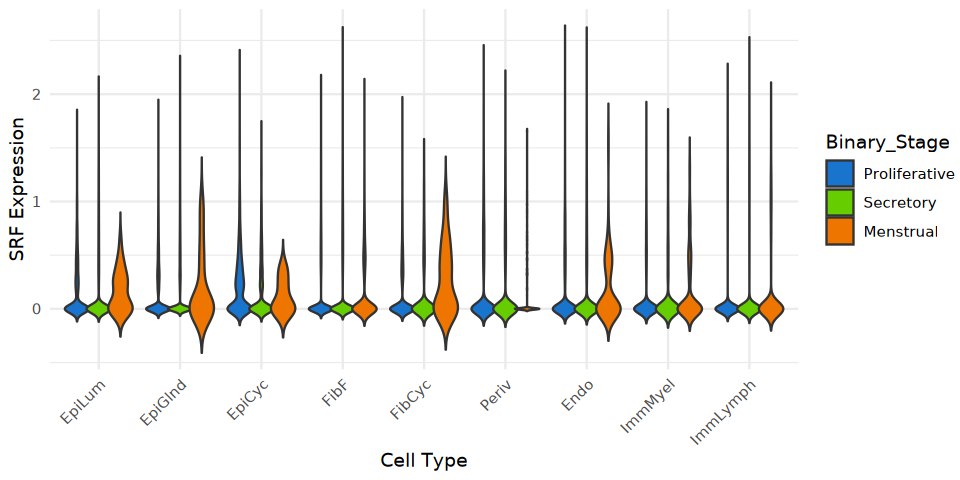

In [271]:
# Set the identities in the Seurat object
Idents(hecaNH) <- hecaNH$celltypeCollapsed

# Extract the data used to create the plot
data <- FetchData(hecaNH, vars = c("SRF", "celltypeCollapsed", "Binary_Stage"))

# Convert celltypeCollapsed to character for easier manipulation
data$celltypeCollapsed <- as.character(data$celltypeCollapsed)

# Filter out the "SMC" and "EndoLymph" groups because they have fewer that 50 cells in the endometriosis datasets, also "other"
data <- data[!data$celltypeCollapsed %in% c("SMC", "EndoLymph", "other"), ]

# Combine the "FibF3" and "FibF2" groups into a single group
data$celltypeCollapsed[data$celltypeCollapsed %in% c("FibF3", "FibF2")] <- "FibF"

# Ensure that only desired groups are included
desired_order <- c("EpiLum", "EpiGlnd", "EpiCyc", "FibF", "FibCyc", "Periv", "Endo", "ImmMyel", "ImmLymph")
data <- data[data$celltypeCollapsed %in% desired_order, ]

# Convert celltypeCollapsed back to factor with the desired order
data$celltypeCollapsed <- factor(data$celltypeCollapsed, levels = desired_order)

# Convert Binary_Stage to character for easier manipulation
data$Binary_Stage <- as.character(data$Binary_Stage)

# Ensure that desired groups are included in desired order
desired_order <- c("Proliferative", "Secretory", "Menstrual")
data <- data[data$Binary_Stage %in% desired_order, ]

# Convert celltypeCollapsed back to factor with the desired order
data$Binary_Stage <- factor(data$Binary_Stage, levels = desired_order)

# Create the base plot with ggplot2 to control the point colors
p <- ggplot(data, aes(x = celltypeCollapsed, y = SRF, fill = Binary_Stage)) +
  geom_violin(position = position_dodge(width = 0.8), scale = "width", trim = FALSE) +
  scale_fill_manual(values = c("dodgerblue3", "chartreuse3", "darkorange2")) +
  scale_color_manual(values = c("dodgerblue3", "chartreuse3", "darkorange2")) +
  theme_minimal() +
  labs(x = "Cell Type", y = "SRF Expression") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

# Print the plot
saved <- options(repr.plot.width = 8, repr.plot.height = 4) # Make the plots bigger from here on out, save old options
p
options(saved) # restore old settings


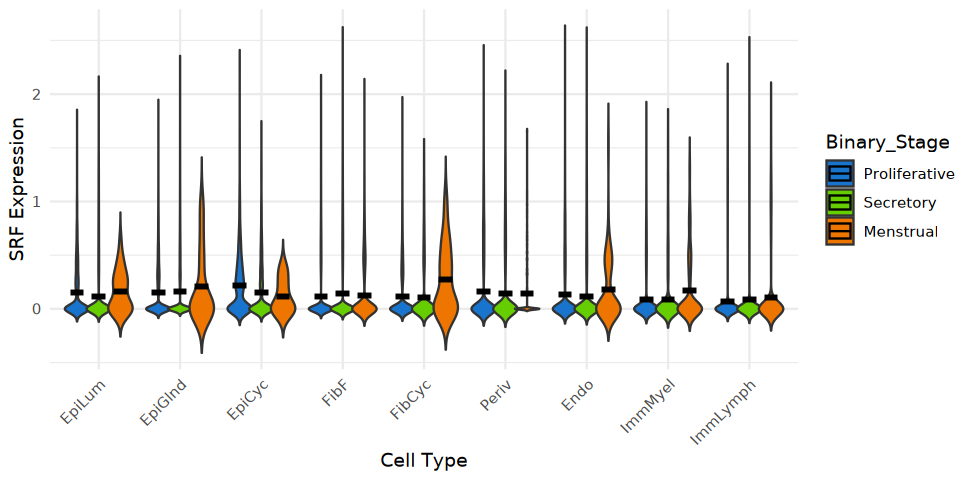

In [275]:
# Set the identities in the Seurat object
Idents(hecaNH) <- hecaNH$celltypeCollapsed

# Extract the data used to create the plot
data <- FetchData(hecaNH, vars = c("SRF", "celltypeCollapsed", "Binary_Stage"))

# Convert celltypeCollapsed to character for easier manipulation
data$celltypeCollapsed <- as.character(data$celltypeCollapsed)

# Filter out the "SMC" and "EndoLymph" groups because they have fewer that 50 cells in the endometriosis datasets, also "other"
data <- data[!data$celltypeCollapsed %in% c("SMC", "EndoLymph", "other"), ]

# Combine the "FibF3" and "FibF2" groups into a single group
data$celltypeCollapsed[data$celltypeCollapsed %in% c("FibF3", "FibF2")] <- "FibF"

# Ensure that only desired groups are included
desired_order <- c("EpiLum", "EpiGlnd", "EpiCyc", "FibF", "FibCyc", "Periv", "Endo", "ImmMyel", "ImmLymph")
data <- data[data$celltypeCollapsed %in% desired_order, ]

# Convert celltypeCollapsed back to factor with the desired order
data$celltypeCollapsed <- factor(data$celltypeCollapsed, levels = desired_order)

# Convert Binary_Stage to character for easier manipulation
data$Binary_Stage <- as.character(data$Binary_Stage)

# Ensure that desired groups are included in desired order
desired_order <- c("Proliferative", "Secretory", "Menstrual")
data <- data[data$Binary_Stage %in% desired_order, ]

# Convert celltypeCollapsed back to factor with the desired order
data$Binary_Stage <- factor(data$Binary_Stage, levels = desired_order)

# Create the base plot with ggplot2 to control the point colors
p <- ggplot(data, aes(x = celltypeCollapsed, y = SRF, fill = Binary_Stage)) +
  geom_violin(position = position_dodge(width = 0.8), scale = "width", trim = FALSE) +
  stat_summary(fun = mean, geom = "crossbar", width = 0.5, position = position_dodge(width = 0.8), colour = "black") +
  scale_fill_manual(values = c("dodgerblue3", "chartreuse3", "darkorange2")) +
  scale_color_manual(values = c("dodgerblue3", "chartreuse3", "darkorange2")) +
  theme_minimal() +
  labs(x = "Cell Type", y = "SRF Expression") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

# Print the plot
saved <- options(repr.plot.width = 8, repr.plot.height = 4) # Make the plots bigger from here on out, save old options
p
options(saved) # restore old settings


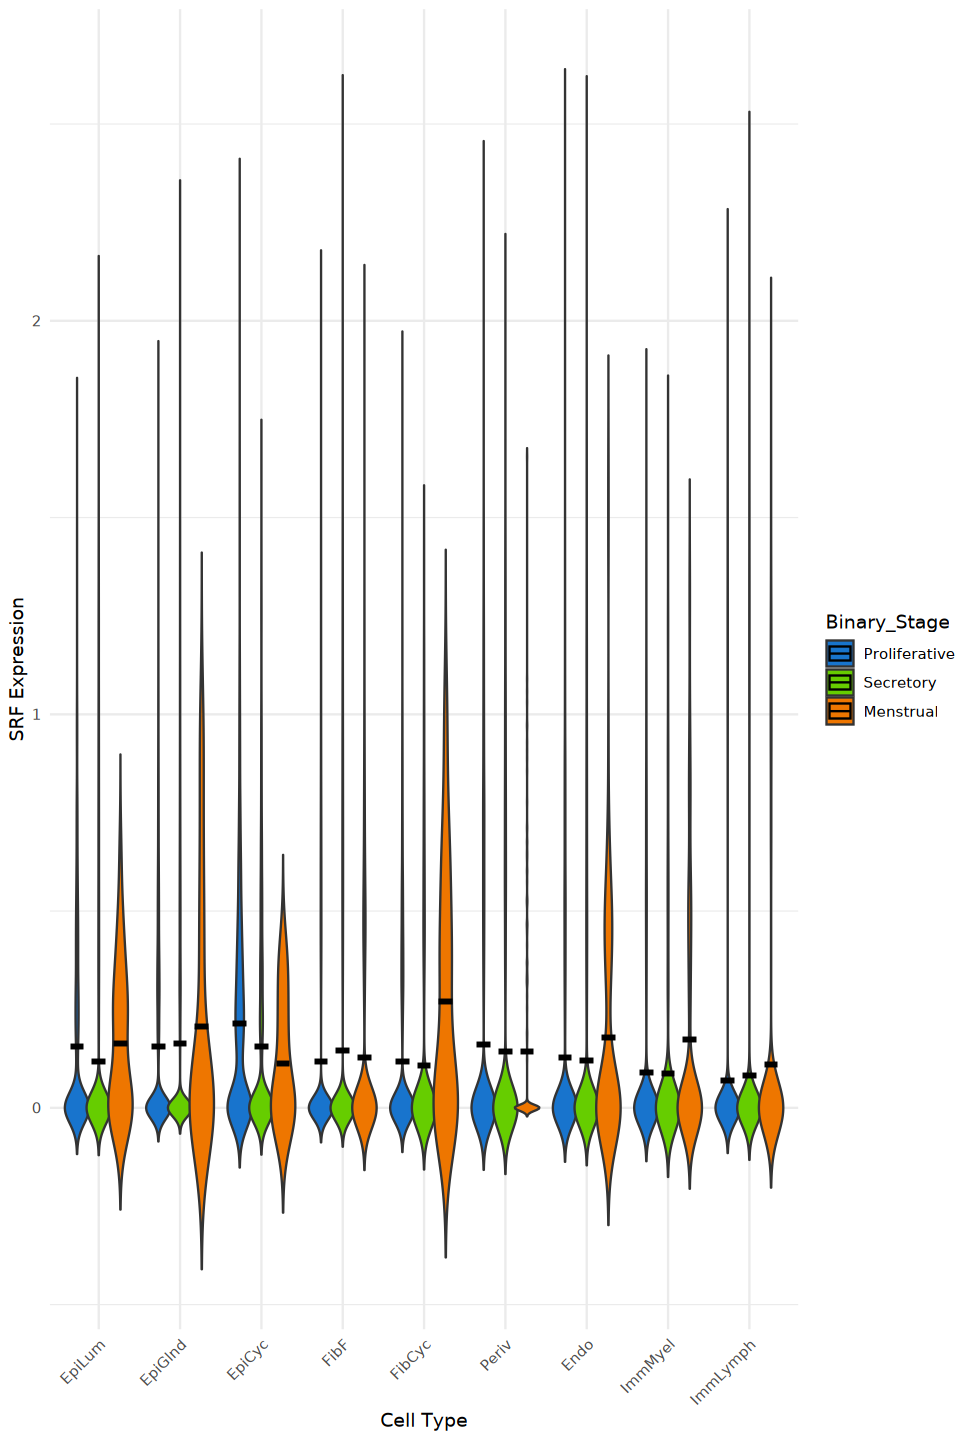

In [302]:
# Set the identities in the Seurat object
Idents(hecaNH) <- hecaNH$celltypeCollapsed

# Extract the data used to create the plot
data <- FetchData(hecaNH, vars = c("SRF", "celltypeCollapsed", "Binary_Stage"))

# Convert celltypeCollapsed to character for easier manipulation
data$celltypeCollapsed <- as.character(data$celltypeCollapsed)

# Filter out the "SMC" and "EndoLymph" groups because they have fewer that 50 cells in the endometriosis datasets, also "other"
data <- data[!data$celltypeCollapsed %in% c("SMC", "EndoLymph", "other"), ]

# Combine the "FibF3" and "FibF2" groups into a single group
data$celltypeCollapsed[data$celltypeCollapsed %in% c("FibF3", "FibF2")] <- "FibF"

# Ensure that only desired groups are included
desired_order <- c("EpiLum", "EpiGlnd", "EpiCyc", "FibF", "FibCyc", "Periv", "Endo", "ImmMyel", "ImmLymph")
data <- data[data$celltypeCollapsed %in% desired_order, ]

# Convert celltypeCollapsed back to factor with the desired order
data$celltypeCollapsed <- factor(data$celltypeCollapsed, levels = desired_order)

# Convert Binary_Stage to character for easier manipulation
data$Binary_Stage <- as.character(data$Binary_Stage)

# Ensure that desired groups are included in desired order
desired_order <- c("Proliferative", "Secretory", "Menstrual")
data <- data[data$Binary_Stage %in% desired_order, ]

# Convert celltypeCollapsed back to factor with the desired order
data$Binary_Stage <- factor(data$Binary_Stage, levels = desired_order)

# Create the base plot with ggplot2 to control the point colors
p <- ggplot(data, aes(x = celltypeCollapsed, y = SRF, fill = Binary_Stage)) +
  geom_violin(position = position_dodge(width = 0.8), scale = "width", trim = FALSE) +
  stat_summary(fun = mean, geom = "crossbar", width = 0.5, position = position_dodge(width = 0.8), colour = "black") +
  scale_fill_manual(values = c("dodgerblue3", "chartreuse3", "darkorange2")) +
  scale_color_manual(values = c("dodgerblue3", "chartreuse3", "darkorange2")) +
  theme_minimal() +
  labs(x = "Cell Type", y = "SRF Expression") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

# Print the plot
saved <- options(repr.plot.width = 8, repr.plot.height = 12) # Make the plots bigger from here on out, save old options
p
options(saved) # restore old settings


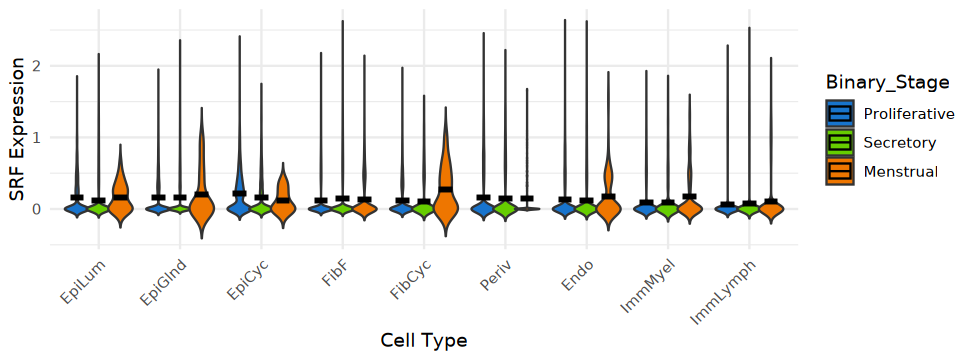

In [303]:
# Set the identities in the Seurat object
Idents(hecaNH) <- hecaNH$celltypeCollapsed

# Extract the data used to create the plot
data <- FetchData(hecaNH, vars = c("SRF", "celltypeCollapsed", "Binary_Stage"))

# Convert celltypeCollapsed to character for easier manipulation
data$celltypeCollapsed <- as.character(data$celltypeCollapsed)

# Filter out the "SMC" and "EndoLymph" groups because they have fewer that 50 cells in the endometriosis datasets, also "other"
data <- data[!data$celltypeCollapsed %in% c("SMC", "EndoLymph", "other"), ]

# Combine the "FibF3" and "FibF2" groups into a single group
data$celltypeCollapsed[data$celltypeCollapsed %in% c("FibF3", "FibF2")] <- "FibF"

# Ensure that only desired groups are included
desired_order <- c("EpiLum", "EpiGlnd", "EpiCyc", "FibF", "FibCyc", "Periv", "Endo", "ImmMyel", "ImmLymph")
data <- data[data$celltypeCollapsed %in% desired_order, ]

# Convert celltypeCollapsed back to factor with the desired order
data$celltypeCollapsed <- factor(data$celltypeCollapsed, levels = desired_order)

# Convert Binary_Stage to character for easier manipulation
data$Binary_Stage <- as.character(data$Binary_Stage)

# Ensure that desired groups are included in desired order
desired_order <- c("Proliferative", "Secretory", "Menstrual")
data <- data[data$Binary_Stage %in% desired_order, ]

# Convert celltypeCollapsed back to factor with the desired order
data$Binary_Stage <- factor(data$Binary_Stage, levels = desired_order)

# Create the base plot with ggplot2 to control the point colors
p <- ggplot(data, aes(x = celltypeCollapsed, y = SRF, fill = Binary_Stage)) +
  geom_violin(position = position_dodge(width = 0.8), scale = "width", trim = FALSE) +
  stat_summary(fun = mean, geom = "crossbar", width = 0.5, position = position_dodge(width = 0.8), colour = "black") +
  scale_fill_manual(values = c("dodgerblue3", "chartreuse3", "darkorange2")) +
  scale_color_manual(values = c("dodgerblue3", "chartreuse3", "darkorange2")) +
  theme_minimal() +
  labs(x = "Cell Type", y = "SRF Expression") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

# Print the plot
saved <- options(repr.plot.width = 8, repr.plot.height = 3) # Make the plots bigger from here on out, save old options
p
options(saved) # restore old settings


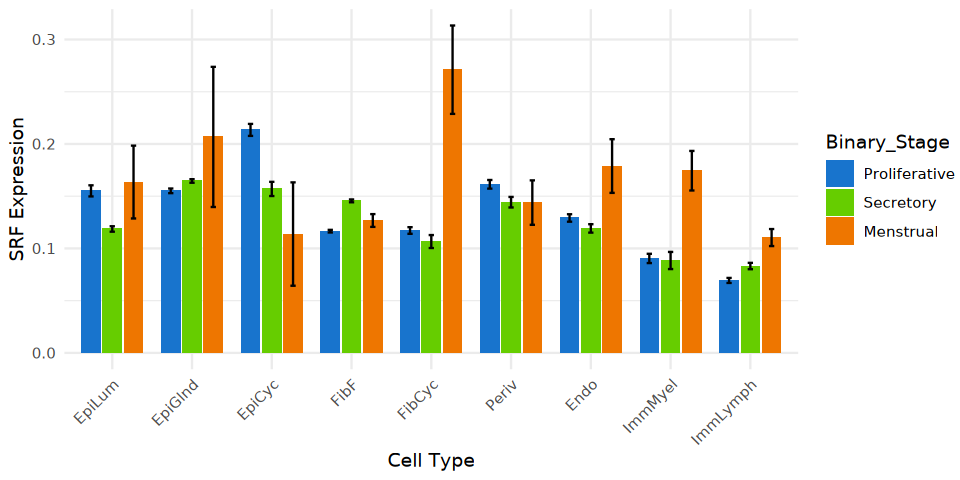

In [291]:
# Set the identities in the Seurat object
Idents(hecaNH) <- hecaNH$celltypeCollapsed

# Extract the data used to create the plot
data <- FetchData(hecaNH, vars = c("SRF", "celltypeCollapsed", "Binary_Stage"))

# Convert celltypeCollapsed to character for easier manipulation
data$celltypeCollapsed <- as.character(data$celltypeCollapsed)

# Filter out the "SMC" and "EndoLymph" groups because they have fewer that 50 cells in the endometriosis datasets, also "other"
data <- data[!data$celltypeCollapsed %in% c("SMC", "EndoLymph", "other"), ]

# Combine the "FibF3" and "FibF2" groups into a single group
data$celltypeCollapsed[data$celltypeCollapsed %in% c("FibF3", "FibF2")] <- "FibF"

# Ensure that only desired groups are included
desired_order <- c("EpiLum", "EpiGlnd", "EpiCyc", "FibF", "FibCyc", "Periv", "Endo", "ImmMyel", "ImmLymph")
data <- data[data$celltypeCollapsed %in% desired_order, ]

# Convert celltypeCollapsed back to factor with the desired order
data$celltypeCollapsed <- factor(data$celltypeCollapsed, levels = desired_order)

# Convert Binary_Stage to character for easier manipulation
data$Binary_Stage <- as.character(data$Binary_Stage)

# Ensure that desired groups are included in desired order
desired_order <- c("Proliferative", "Secretory", "Menstrual")
data <- data[data$Binary_Stage %in% desired_order, ]

# Convert celltypeCollapsed back to factor with the desired order
data$Binary_Stage <- factor(data$Binary_Stage, levels = desired_order)

# Create the base plot with ggplot2 to control the point colors
p <- ggplot(data, aes(x = celltypeCollapsed, y = SRF, fill = Binary_Stage)) +
  stat_summary(
    fun = mean,
    geom = "bar",
    position = position_dodge(width = 0.8),
    width = 0.7
  ) +
  stat_summary(
    fun.data = mean_se,
    geom = "errorbar",
    width = 0.2,
    position = position_dodge(width = 0.8),
    colour = "black"
  ) +
  scale_fill_manual(values = c("dodgerblue3", "chartreuse3", "darkorange2")) +
  scale_color_manual(values = c("dodgerblue3", "chartreuse3", "darkorange2")) +
  theme_minimal() +
  labs(x = "Cell Type", y = "SRF Expression") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

# Print the plot
saved <- options(repr.plot.width = 8, repr.plot.height = 4) # Make the plots bigger from here on out, save old options
p
options(saved) # restore old settings


Warning message:
“Groups with fewer than two data points have been dropped.”


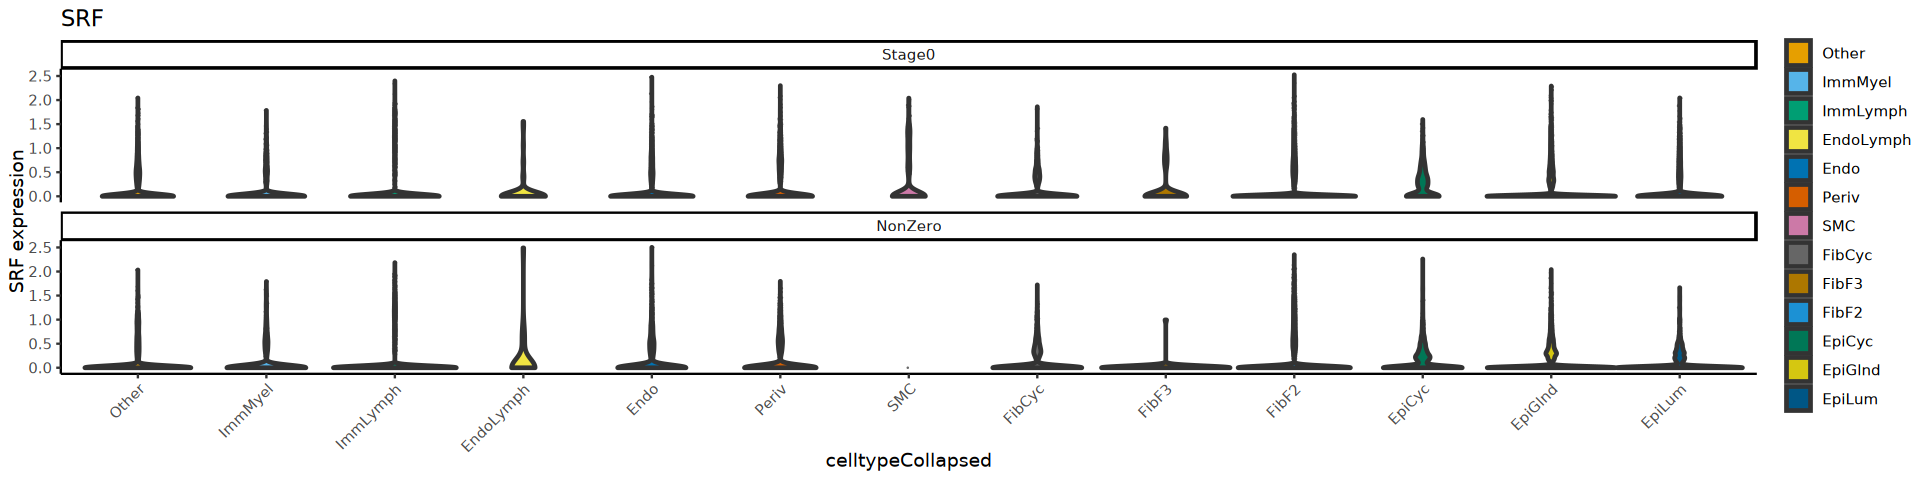

In [119]:
# SRF violin Plot by cell type/pathology

Idents(hecaNH) <- hecaNH$celltypeCollapsed

saved <- options(repr.plot.width = 16, repr.plot.height = 4) # Make the plots bigger from here on out, save old options
dittoPlot(hecaNH, "SRF", 
        group.by = "celltypeCollapsed",
        plots = c("jitter", "vlnplot"),
        jitter.color = c("dimgrey"), jitter.size = 0.1,
        split.by="binary_pathology",
        split.nrow = 2
)

options(saved) # restore old settings

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


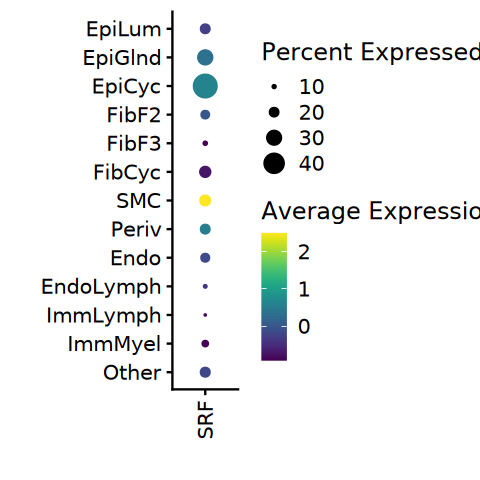

In [26]:
# SRF dotplot by cell type

genes <- c("SRF")

Idents(hecaNH) <- hecaNH$celltypeCollapsed

saved <- options(repr.plot.width = 4, repr.plot.height = 4) # Make the plots bigger from here on out, save old options

DotPlot(hecaNH, features=genes) + RotatedAxis() + scale_color_viridis(option="D") + theme(axis.text.x=element_text(angle=90, vjust=0.5, hjust=1)) + ylab('') + xlab('');
       

options(saved) # restore old settings

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



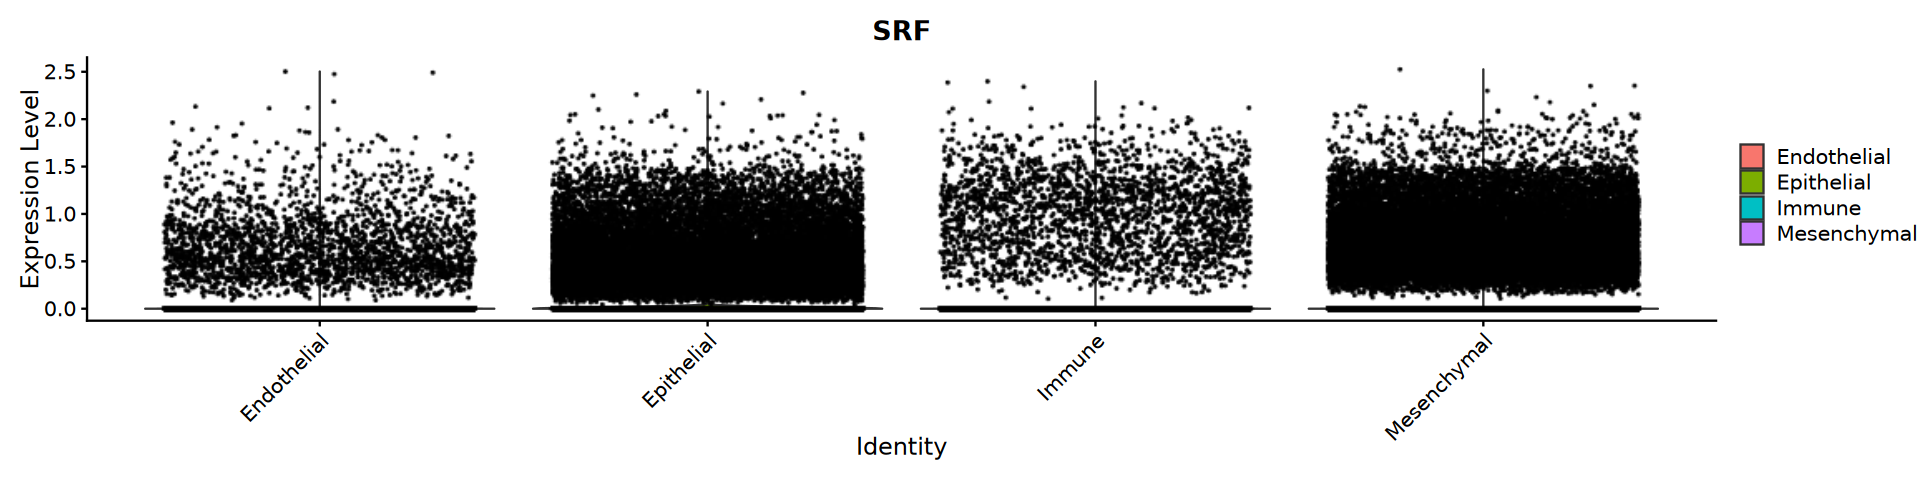

In [34]:
# SRF violin Plot by cell lineage

Idents(hecaNH) <- hecaNH$lineage

saved <- options(repr.plot.width = 16, repr.plot.height = 4) # Make the plots bigger from here on out, save old options
VlnPlot(hecaNH, features = c("SRF"), 
        group.by = "lineage",
        pt.size = 0.1)

options(saved) # restore old settings

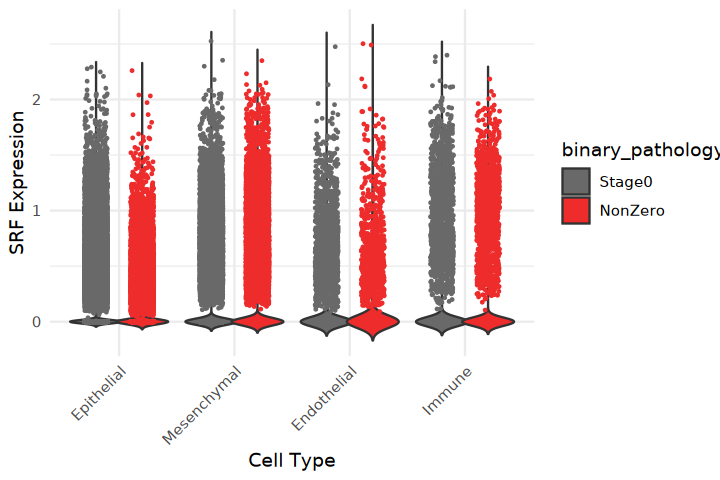

In [159]:
# Set the identities in the Seurat object
Idents(hecaNH) <- hecaNH$lineage

# Extract the data used to create the plot
data <- FetchData(hecaNH, vars = c("SRF", "lineage", "binary_pathology"))

# Convert lineage to character for easier manipulation
data$lineage <- as.character(data$lineage)

# Ensure that only desired groups are included
desired_order <- c("Epithelial", "Mesenchymal", "Endothelial", "Immune")
data <- data[data$lineage %in% desired_order, ]

# Convert celltypeCollapsed back to factor with the desired order
data$lineage <- factor(data$lineage, levels = desired_order)

# Create the base plot with ggplot2 to control the point colors
p <- ggplot(data, aes(x = lineage, y = SRF, fill = binary_pathology)) +
  geom_violin(position = position_dodge(width = 0.8), scale = "width", trim = FALSE) +
  geom_jitter(aes(color = binary_pathology), position = position_jitterdodge(jitter.width = 0.4, dodge.width = 0.8), size = 0.3) +
  scale_fill_manual(values = c("dimgrey", "firebrick2")) +
  scale_color_manual(values = c("dimgrey", "firebrick2")) +
  theme_minimal() +
  labs(x = "Cell Type", y = "SRF Expression") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

# Print the plot
saved <- options(repr.plot.width = 6, repr.plot.height = 4) # Make the plots bigger from here on out, save old options
p
options(saved) # restore old settings


Warning message:
“Scaling data with a low number of groups may produce misleading results”
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


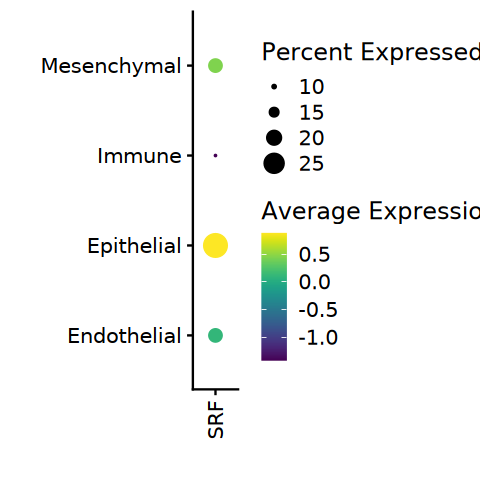

In [25]:
# SRF dotplot by cell lineage

genes <- c("SRF")

Idents(hecaNH) <- hecaNH$lineage

saved <- options(repr.plot.width = 4, repr.plot.height = 4) # Make the plots bigger from here on out, save old options

DotPlot(hecaNH, features=genes) + RotatedAxis() + scale_color_viridis(option="D") + theme(axis.text.x=element_text(angle=90, vjust=0.5, hjust=1)) + ylab('') + xlab('');
       

options(saved) # restore old settings

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



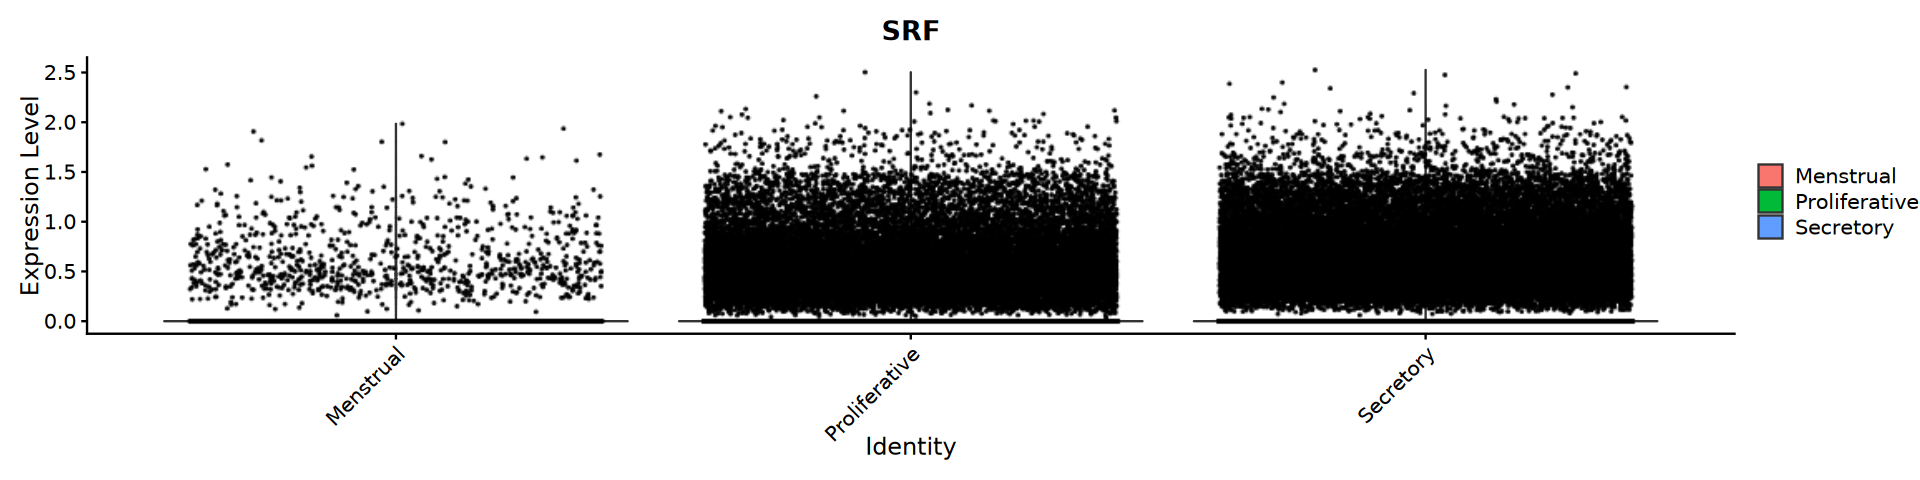

In [33]:
# SRF violin Plot by cycle stage

Idents(hecaNH) <- hecaNH$Binary_Stage

saved <- options(repr.plot.width = 16, repr.plot.height = 4) # Make the plots bigger from here on out, save old options
VlnPlot(hecaNH, features = c("SRF"), 
        group.by = "Binary_Stage",
        pt.size = 0.1)

options(saved) # restore old settings

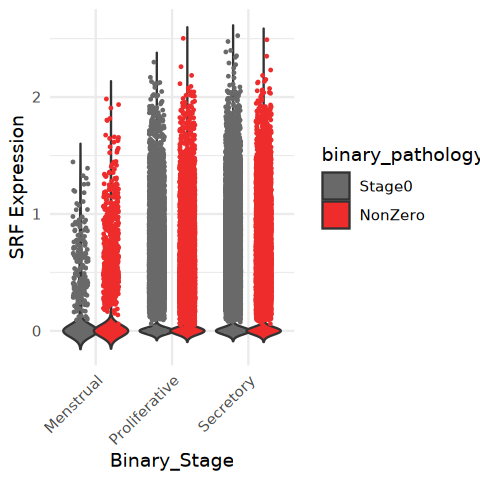

In [161]:
# Set the identities in the Seurat object
Idents(hecaNH) <- hecaNH$Binary_Stage

# Extract the data used to create the plot
data <- FetchData(hecaNH, vars = c("SRF", "Binary_Stage", "binary_pathology"))

# Create the base plot with ggplot2 to control the point colors
p <- ggplot(data, aes(x = Binary_Stage, y = SRF, fill = binary_pathology)) +
  geom_violin(position = position_dodge(width = 0.8), scale = "width", trim = FALSE) +
  geom_jitter(aes(color = binary_pathology), position = position_jitterdodge(jitter.width = 0.4, dodge.width = 0.8), size = 0.3) +
  scale_fill_manual(values = c("dimgrey", "firebrick2")) +
  scale_color_manual(values = c("dimgrey", "firebrick2")) +
  theme_minimal() +
  labs(x = "Binary_Stage", y = "SRF Expression") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

# Print the plot
saved <- options(repr.plot.width = 4, repr.plot.height = 4) # Make the plots bigger from here on out, save old options
p
options(saved) # restore old settings


Warning message:
“Scaling data with a low number of groups may produce misleading results”
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


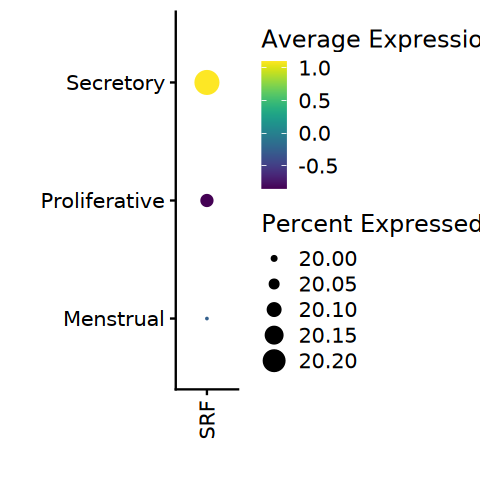

In [36]:
# SRF dotplot by cycle stage

genes <- c("SRF")

Idents(hecaNH) <- hecaNH$Binary_Stage

saved <- options(repr.plot.width = 4, repr.plot.height = 4) # Make the plots bigger from here on out, save old options

DotPlot(hecaNH, features=genes) + RotatedAxis() + scale_color_viridis(option="D") + theme(axis.text.x=element_text(angle=90, vjust=0.5, hjust=1)) + ylab('') + xlab('');
       

options(saved) # restore old settings

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



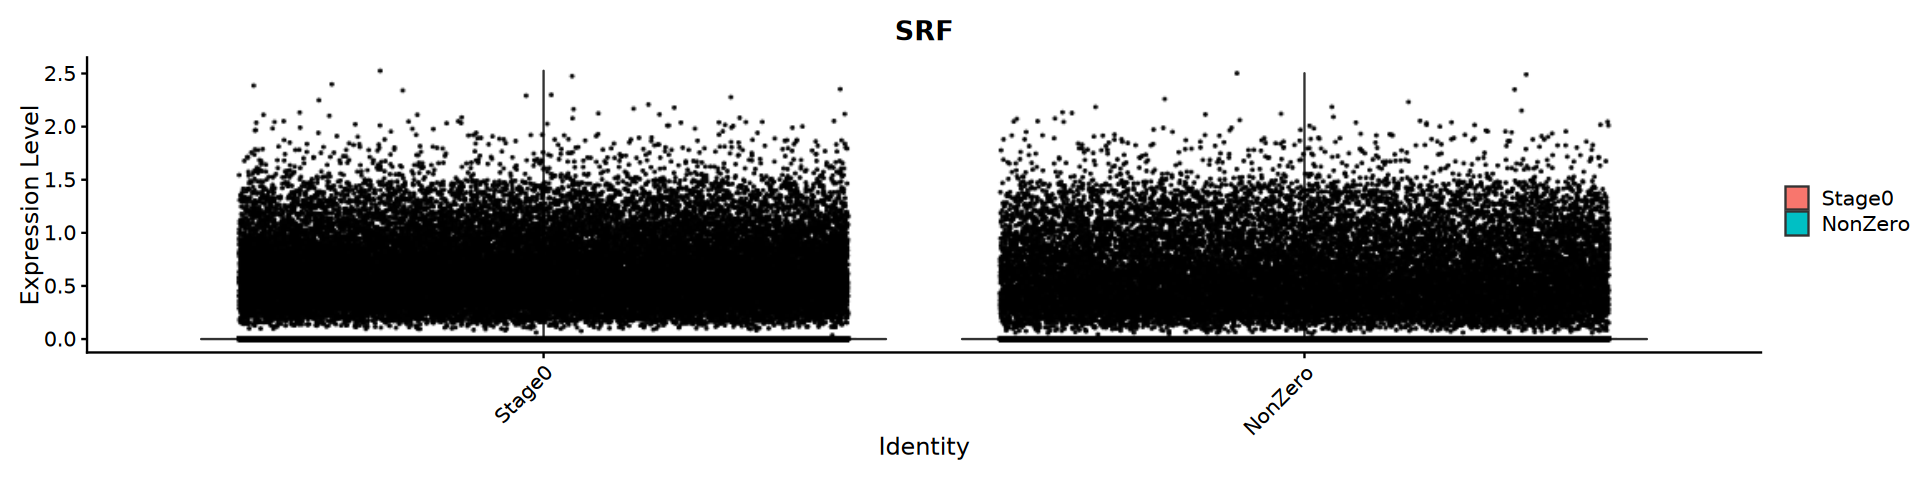

In [32]:
# SRF violin Plot by pathology status

Idents(hecaNH) <- hecaNH$binary_pathology

saved <- options(repr.plot.width = 16, repr.plot.height = 4) # Make the plots bigger from here on out, save old options
VlnPlot(hecaNH, features = c("SRF"), 
        group.by = "binary_pathology",
        pt.size = 0.1)

options(saved) # restore old settings

Warning message:
“Scaling data with a low number of groups may produce misleading results”
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


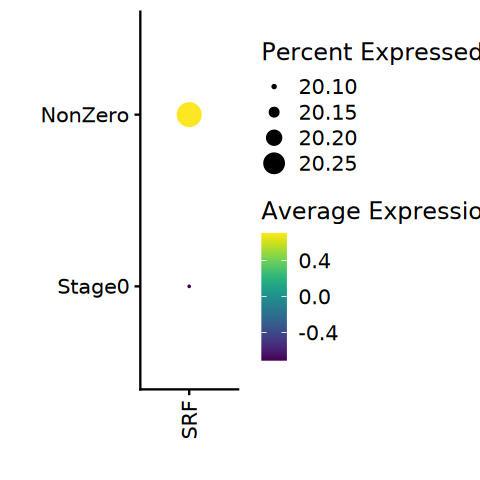

In [39]:
# SRF dotplot by pathology status

genes <- c("SRF")

Idents(hecaNH) <- hecaNH$binary_pathology

saved <- options(repr.plot.width = 4, repr.plot.height = 4) # Make the plots bigger from here on out, save old options

DotPlot(hecaNH, features=genes) + RotatedAxis() + scale_color_viridis(option="D") + theme(axis.text.x=element_text(angle=90, vjust=0.5, hjust=1)) + ylab('') + xlab('');
       

options(saved) # restore old settings

In [167]:
head(hecaNH)

,n_genes,sample,library,Processing,Treatment,percent_mito,n_counts,scrublet_score,genotype,Library_genotype,⋯,lineage,label_long,orig.ident,nCount_RNA,nFeature_RNA,Hormonal_treatment,Tenx_kit,Binary_Stage,binary_pathology,celltypeCollapsed
,<int>,<fct>,<fct>,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<fct>,<fct>,⋯,<fct>,<fct>,<fct>,<dbl>,<dbl>,<fct>,<fct>,<fct>,<fct>,<fct>
HCA_A_RepT_RNA13247830_AAACCTGAGCGATGAC-Mareckova,1981,HCA_A_RepT_RNA13247830,HCA_A_RepT_RNA13247830,Fresh,Coll.+Trypsin,0.03678274,3956,0.03315650,A70,HCA_A_RepT_RNA13247830_A70,⋯,Mesenchymal,19 | ePV 1a,HCA,3956,1901,nan,3' v3.1,Proliferative,Stage0,Periv
HCA_A_RepT_RNA13247830_AAACCTGAGCTAGGCA-Mareckova,3492,HCA_A_RepT_RNA13247830,HCA_A_RepT_RNA13247830,Fresh,Coll.+Trypsin,0.04224921,9546,0.02918782,A70,HCA_A_RepT_RNA13247830_A70,⋯,Mesenchymal,23 | eStromal,HCA,9546,3336,nan,3' v3.1,Proliferative,Stage0,FibF2
HCA_A_RepT_RNA13247830_AAACCTGCACCAACCG-Mareckova,2967,HCA_A_RepT_RNA13247830,HCA_A_RepT_RNA13247830,Fresh,Coll.+Trypsin,0.09299796,7188,0.07558140,A70,HCA_A_RepT_RNA13247830_A70,⋯,Endothelial,32 | Venous,HCA,7188,2850,nan,3' v3.1,Proliferative,Stage0,Endo
HCA_A_RepT_RNA13247830_AAACCTGCACCTGGTG-Mareckova,2597,HCA_A_RepT_RNA13247830,HCA_A_RepT_RNA13247830,Fresh,Coll.+Trypsin,0.03544836,6029,0.06925208,A70,HCA_A_RepT_RNA13247830_A70,⋯,Mesenchymal,18 | mPV,HCA,6029,2484,nan,3' v3.1,Proliferative,Stage0,Periv
HCA_A_RepT_RNA13247830_AAACCTGCATAGAAAC-Mareckova,3319,HCA_A_RepT_RNA13247830,HCA_A_RepT_RNA13247830,Fresh,Coll.+Trypsin,0.03645893,8571,0.05496308,A70,HCA_A_RepT_RNA13247830_A70,⋯,Endothelial,32 | Venous,HCA,8571,3179,nan,3' v3.1,Proliferative,Stage0,Endo
HCA_A_RepT_RNA13247830_AAACCTGCATTTCAGG-Mareckova,3731,HCA_A_RepT_RNA13247830,HCA_A_RepT_RNA13247830,Fresh,Coll.+Trypsin,0.06638157,10053,0.08256881,A70,HCA_A_RepT_RNA13247830_A70,⋯,Endothelial,32 | Venous,HCA,10053,3570,nan,3' v3.1,Proliferative,Stage0,Endo
HCA_A_RepT_RNA13247830_AAACCTGGTGGTTTCA-Mareckova,3652,HCA_A_RepT_RNA13247830,HCA_A_RepT_RNA13247830,Fresh,Coll.+Trypsin,0.09278455,9636,0.04754601,A70,HCA_A_RepT_RNA13247830_A70,⋯,Mesenchymal,17 | uSMCs,HCA,9636,3461,nan,3' v3.1,Proliferative,Stage0,SMC
HCA_A_RepT_RNA13247830_AAACCTGTCAGCCTAA-Mareckova,2488,HCA_A_RepT_RNA13247830,HCA_A_RepT_RNA13247830,Fresh,Coll.+Trypsin,0.09697344,6364,0.04895105,A70,HCA_A_RepT_RNA13247830_A70,⋯,Mesenchymal,19 | ePV 1a,HCA,6364,2402,nan,3' v3.1,Proliferative,Stage0,Periv
HCA_A_RepT_RNA13247830_AAACCTGTCCAAGCCG-Mareckova,1804,HCA_A_RepT_RNA13247830,HCA_A_RepT_RNA13247830,Fresh,Coll.+Trypsin,0.09187965,3032,0.11220715,A70,HCA_A_RepT_RNA13247830_A70,⋯,Endothelial,32 | Venous,HCA,3032,1752,nan,3' v3.1,Proliferative,Stage0,Endo


In [218]:
levels(hecaNH$celltypeCollapsed)

[1] "Other"     "ImmMyel"   "ImmLymph"  "EndoLymph" "Endo"      "Periv"    
 [7] "SMC"       "FibCyc"    "FibF3"     "FibF2"     "EpiCyc"    "EpiGlnd"  
[13] "EpiLum"

In [222]:
# Let's make a cell type and phase-specific dotplot follwing instructions from https://divingintogeneticsandgenomics.com/post/how-to-make-a-multi-group-dotplot-for-single-cell-rnaseq-data/

# Customized multi-group dotplot
# We need to get the percentage of positive cells and average expression by group.
# For a single gene, put the groups into multiple rows, and each column is a cell type.

# group1 is the cell type/cluster annotation 
# group2 is any condition you want to further group, in this case, the phase

#This first part is just copy and paste from the link to prepare the function; no customization

GetMatrixFromSeuratByGroupSingle<- function(obj, feature, group1, group2){
  if (length(feature) != 1){
          stop("please only provide only one gene name")
  }
  exp_mat<- obj@assays$RNA$data[feature, ,drop=FALSE]
  count_mat<- obj@assays$RNA$counts[feature,,drop=FALSE ]
  
  meta<- obj@meta.data %>%
  tibble::rownames_to_column(var = "cell")
        
  # get the average expression matrix
  exp_df<- as.matrix(exp_mat) %>% 
    as.data.frame() %>% 
    tibble::rownames_to_column(var="gene") %>%
    tidyr::pivot_longer(!gene, names_to = "cell", values_to = "expression") %>%
    left_join(meta) %>%
    group_by(gene,{{group1}}, {{group2}}) %>%
    summarise(average_expression = mean(expression)) %>%
    tidyr::pivot_wider(names_from = {{group1}}, 
                       values_from= average_expression) 
  
  exp_mat<- exp_df[, -c(1,2)] %>% as.matrix()
  rownames(exp_mat)<- exp_df %>% pull({{group2}})
  
  # get the percentage positive cell matrix
  count_df<- as.matrix(count_mat) %>% 
    as.data.frame() %>% 
    tibble::rownames_to_column(var="gene") %>%
    tidyr::pivot_longer(!gene, names_to = "cell", values_to = "count") %>%
    left_join(meta) %>%
    group_by(gene, {{group1}}, {{group2}}) %>%
    summarise(percentage = mean(count >0)) %>%
    tidyr::pivot_wider(names_from = {{group1}}, 
                       values_from= percentage) 

  percent_mat<- count_df[, -c(1,2)] %>% as.matrix()
  rownames(percent_mat)<- count_df %>% pull({{group2}})
  
  if (!identical(dim(exp_mat), dim(percent_mat))) {
    stop("the dimension of the two matrice should be the same!")
  }
  
  if(! all.equal(colnames(exp_mat), colnames(percent_mat))) {
    stop("column names of the two matrice should be the same!")
  }
  
  if(! all.equal(rownames(exp_mat), rownames(percent_mat))) {
    stop("column names of the two matrice should be the same!")
  }
  return(list(exp_mat = exp_mat, percent_mat = percent_mat))
}



In [223]:
# Let’s get the matrices for one gene

# This is where we enter our object name, feature of interest, and condition names from the object metadata

mat<- GetMatrixFromSeuratByGroupSingle(obj= hecaNH, 
                                 feature = "SRF", 
                                 lineage,
                                 Binary_Stage)

# take a look at the matrices

# 1. the average expression for each cell type per condition
mat$exp_mat

# 2. the percentage of cells positive for the gene of interest for each cell type per condition
mat$percent_mat

Joining with `by = join_by(cell)`
`summarise()` has grouped output by 'gene', 'lineage'. You can override using
the `.groups` argument.
Joining with `by = join_by(cell)`
`summarise()` has grouped output by 'gene', 'lineage'. You can override using
the `.groups` argument.


,Endothelial,Epithelial,Immune,Mesenchymal
Menstrual,0.1696799,0.1225190,0.11966882,0.1323089
Proliferative,0.1281713,0.1524357,0.07335929,0.1231093
Secretory,0.1194203,0.1530905,0.08361788,0.1416783


,Endothelial,Epithelial,Immune,Mesenchymal
Menstrual,0.3235294,0.3358779,0.13731656,0.2309513
Proliferative,0.1983319,0.3513111,0.07392161,0.1846538
Secretory,0.1676997,0.2567892,0.07996867,0.1859301


In [224]:
# Now, Let’s visualize it using ComplexHeatmap
# Always explore the data range before you decide how to map the data values to colors.

quantile(mat$exp_mat, c(0.1, 0.5, 0.8, 0.9))

10%        50%        80%        90% 
0.08719812 0.12564026 0.15028419 0.15302500

In [219]:
# In this case, 0 will be mapped to #FDE725FF, 0.126 will be mapped to #238A8DFF and 0.17 will be mapped to #440154FF. The value in-between will be linearlly interpolated to get corresponding colors

col_fun<-  circlize::colorRamp2(c(0, 0.126, 0.17), c("#440154FF", "#238A8DFF", "#FDE725FF"))

In [225]:
# Use the layer_fun to decide the size of the dots. 
# Within the grid.circle, we specify the radius r= sqrt(pindex(mat$percent_mat, i, j)) of the circle to be the square root of the percentage
# so the area size of the dots correspond to the percentage.

layer_fun = function(j, i, x, y, w, h, fill){
    grid.rect(x = x, y = y, width = w, height = h, 
              gp = gpar(col = "gray", fill = NA))
    grid.circle(x=x,y=y,r= sqrt(pindex(mat$percent_mat, i, j)) * unit(4, "mm"),
                gp = gpar(fill = col_fun(pindex(mat$exp_mat, i, j)), col = NA))}
  
hp<- Heatmap(mat$exp_mat,
             heatmap_legend_param=list(title= "Expression   "),
             column_title = "SRF",
             column_title_gp = gpar(fontsize = 12, fontface = "bold"),
             width = unit(15, "cm"), # customize width of entire plot
             height = unit(5, "cm"), # customize height of entire plot
             column_names_rot = 45, # customize rotation of column names
             col=col_fun,
             rect_gp = gpar(type = "none"),
             layer_fun = layer_fun,
             row_names_gp = gpar(fontsize = 12), # customize size of row label text
             border = "black",
             cluster_rows = FALSE, 
             cluster_columns = FALSE,
             row_names_side  = "left")

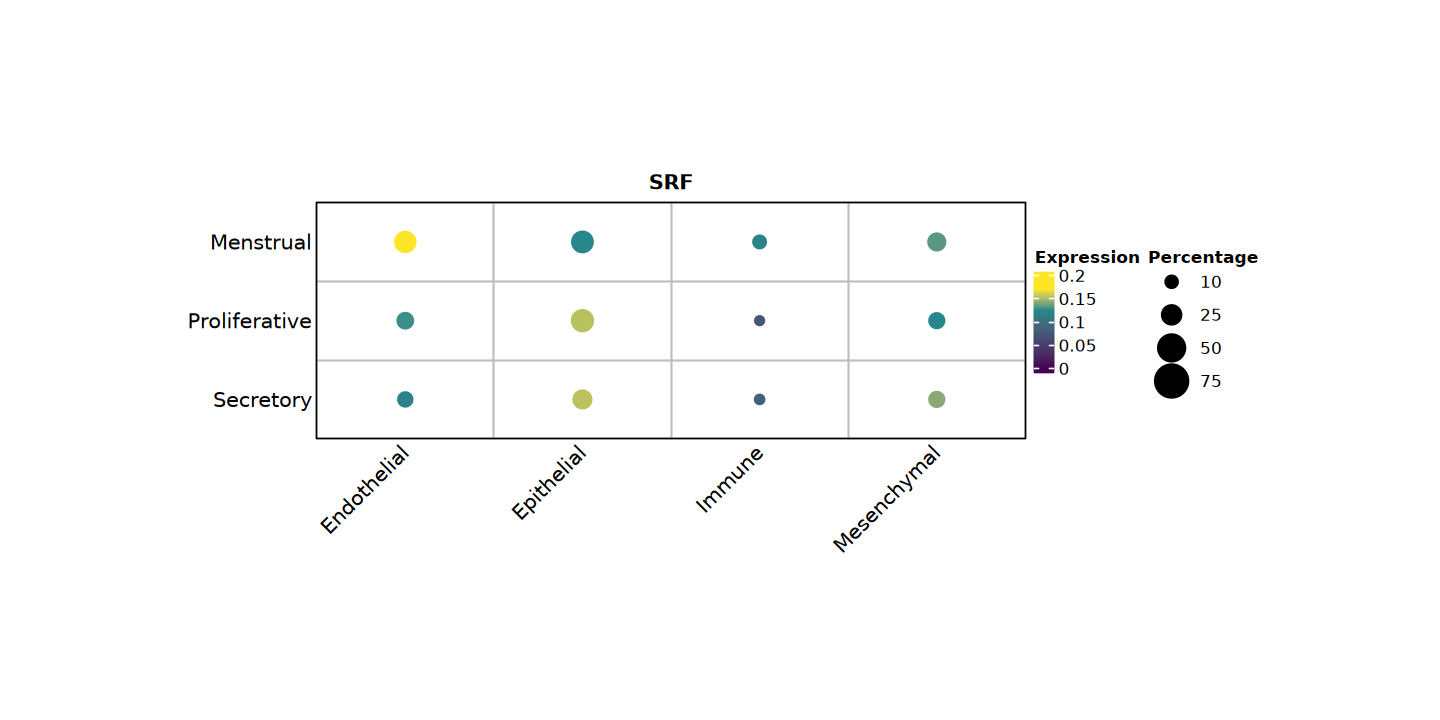

In [226]:
# Make the legend for the dot size. 
# Make sure the size is the same as the in the layer_fun which is unit(4, "mm"). You can change the size as you want.

lgd_list = list(
    Legend( labels = c(10, 25, 50, 75), title = "Percentage",
            graphics = list(
              function(x, y, w, h) grid.circle(x = x, y = y, r = sqrt(0.1)  * unit(4, "mm"),
                                               gp = gpar(fill = "black")),
              function(x, y, w, h) grid.circle(x = x, y = y, r = sqrt(0.25) * unit(4, "mm"),
                                               gp = gpar(fill = "black")),
              function(x, y, w, h) grid.circle(x = x, y = y, r = sqrt(0.5) * unit(4, "mm"),
                                               gp = gpar(fill = "black")),
              function(x, y, w, h) grid.circle(x = x, y = y, r = sqrt(0.75) * unit(4, "mm"),
                                               gp = gpar(fill = "black"))),
            labels_gp = gpar(fontsize = 10), 
            labels_rot = 0,
            legend_height = NULL, legend_width = NULL,
            title_gp = gpar(fontsize = 10, fontface = "bold"),
            row_gap = unit(3, "mm"),
            grid_width = unit(10, "mm")
            ))
    
# Now draw the plot
saved <- options(repr.plot.width = 12, repr.plot.height = 6) # Make the plots bigger from here on out, save old options
draw(hp, annotation_legend_list = lgd_list, ht_gap = unit(1, "cm"),
     annotation_legend_side = "right")
options(saved) # restore old settings

In [228]:
# Use more granular cell types after making some modifications

# Assuming your Seurat object is named `hecaNH`
# Create a copy of the Seurat object
hecaNH_copy <- hecaNH

# Remove cells with the 'Other' level in the copy
hecaNH_copy <- subset(hecaNH_copy, idents = "Other", invert = TRUE)

# Update the 'celltypeCollapsed' column to pool levels in the copy
hecaNH_copy$celltypeCollapsed <- as.character(hecaNH_copy$celltypeCollapsed)

# Pool 'FibF3' and 'FibF2' into one level
hecaNH_copy$celltypeCollapsed[hecaNH_copy$celltypeCollapsed %in% c('FibF3', 'FibF2')] <- 'Fibroblast'

# Pool 'SMC' and 'Periv' into one level
hecaNH_copy$celltypeCollapsed[hecaNH_copy$celltypeCollapsed %in% c('SMC', 'Periv')] <- 'SMC_Periv'

# Pool 'Endo' and 'EndoLymph' into one level
hecaNH_copy$celltypeCollapsed[hecaNH_copy$celltypeCollapsed %in% c('Endo', 'EndoLymph')] <- 'Endothelial'

# Pool 'Endo' and 'EndoLymph' into one level
hecaNH_copy$celltypeCollapsed[hecaNH_copy$celltypeCollapsed %in% c('ImmLymph', 'ImmMyel')] <- 'Immune'

# Convert back to a factor (if needed)
hecaNH_copy$celltypeCollapsed <- factor(hecaNH_copy$celltypeCollapsed)

# Update the identities based on the new cell type column in the copy
Idents(hecaNH_copy) <- hecaNH_copy$celltypeCollapsed

# Check the new levels to confirm
levels(hecaNH_copy$celltypeCollapsed)


[1] "Endothelial" "EpiCyc"      "EpiGlnd"     "EpiLum"      "FibCyc"     
[6] "Fibroblast"  "Immune"      "SMC_Periv"

In [229]:
head(hecaNH_copy)

,n_genes,sample,library,Processing,Treatment,percent_mito,n_counts,scrublet_score,genotype,Library_genotype,⋯,lineage,label_long,orig.ident,nCount_RNA,nFeature_RNA,Hormonal_treatment,Tenx_kit,Binary_Stage,binary_pathology,celltypeCollapsed
,<int>,<fct>,<fct>,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<fct>,<fct>,⋯,<fct>,<fct>,<fct>,<dbl>,<dbl>,<fct>,<fct>,<fct>,<fct>,<fct>
HCA_A_RepT_RNA13247830_AAACCTGAGCGATGAC-Mareckova,1981,HCA_A_RepT_RNA13247830,HCA_A_RepT_RNA13247830,Fresh,Coll.+Trypsin,0.03678274,3956,0.03315650,A70,HCA_A_RepT_RNA13247830_A70,⋯,Mesenchymal,19 | ePV 1a,HCA,3956,1901,nan,3' v3.1,Proliferative,Stage0,SMC_Periv
HCA_A_RepT_RNA13247830_AAACCTGAGCTAGGCA-Mareckova,3492,HCA_A_RepT_RNA13247830,HCA_A_RepT_RNA13247830,Fresh,Coll.+Trypsin,0.04224921,9546,0.02918782,A70,HCA_A_RepT_RNA13247830_A70,⋯,Mesenchymal,23 | eStromal,HCA,9546,3336,nan,3' v3.1,Proliferative,Stage0,Fibroblast
HCA_A_RepT_RNA13247830_AAACCTGCACCAACCG-Mareckova,2967,HCA_A_RepT_RNA13247830,HCA_A_RepT_RNA13247830,Fresh,Coll.+Trypsin,0.09299796,7188,0.07558140,A70,HCA_A_RepT_RNA13247830_A70,⋯,Endothelial,32 | Venous,HCA,7188,2850,nan,3' v3.1,Proliferative,Stage0,Endothelial
HCA_A_RepT_RNA13247830_AAACCTGCACCTGGTG-Mareckova,2597,HCA_A_RepT_RNA13247830,HCA_A_RepT_RNA13247830,Fresh,Coll.+Trypsin,0.03544836,6029,0.06925208,A70,HCA_A_RepT_RNA13247830_A70,⋯,Mesenchymal,18 | mPV,HCA,6029,2484,nan,3' v3.1,Proliferative,Stage0,SMC_Periv
HCA_A_RepT_RNA13247830_AAACCTGCATAGAAAC-Mareckova,3319,HCA_A_RepT_RNA13247830,HCA_A_RepT_RNA13247830,Fresh,Coll.+Trypsin,0.03645893,8571,0.05496308,A70,HCA_A_RepT_RNA13247830_A70,⋯,Endothelial,32 | Venous,HCA,8571,3179,nan,3' v3.1,Proliferative,Stage0,Endothelial
HCA_A_RepT_RNA13247830_AAACCTGCATTTCAGG-Mareckova,3731,HCA_A_RepT_RNA13247830,HCA_A_RepT_RNA13247830,Fresh,Coll.+Trypsin,0.06638157,10053,0.08256881,A70,HCA_A_RepT_RNA13247830_A70,⋯,Endothelial,32 | Venous,HCA,10053,3570,nan,3' v3.1,Proliferative,Stage0,Endothelial
HCA_A_RepT_RNA13247830_AAACCTGGTGGTTTCA-Mareckova,3652,HCA_A_RepT_RNA13247830,HCA_A_RepT_RNA13247830,Fresh,Coll.+Trypsin,0.09278455,9636,0.04754601,A70,HCA_A_RepT_RNA13247830_A70,⋯,Mesenchymal,17 | uSMCs,HCA,9636,3461,nan,3' v3.1,Proliferative,Stage0,SMC_Periv
HCA_A_RepT_RNA13247830_AAACCTGTCAGCCTAA-Mareckova,2488,HCA_A_RepT_RNA13247830,HCA_A_RepT_RNA13247830,Fresh,Coll.+Trypsin,0.09697344,6364,0.04895105,A70,HCA_A_RepT_RNA13247830_A70,⋯,Mesenchymal,19 | ePV 1a,HCA,6364,2402,nan,3' v3.1,Proliferative,Stage0,SMC_Periv
HCA_A_RepT_RNA13247830_AAACCTGTCCAAGCCG-Mareckova,1804,HCA_A_RepT_RNA13247830,HCA_A_RepT_RNA13247830,Fresh,Coll.+Trypsin,0.09187965,3032,0.11220715,A70,HCA_A_RepT_RNA13247830_A70,⋯,Endothelial,32 | Venous,HCA,3032,1752,nan,3' v3.1,Proliferative,Stage0,Endothelial


In [230]:
# Let's make a cell type and phase-specific dotplot follwing instructions from https://divingintogeneticsandgenomics.com/post/how-to-make-a-multi-group-dotplot-for-single-cell-rnaseq-data/

# Customized multi-group dotplot
# We need to get the percentage of positive cells and average expression by group.
# For a single gene, put the groups into multiple rows, and each column is a cell type.

# group1 is the cell type/cluster annotation 
# group2 is any condition you want to further group, in this case, the phase

#This first part is just copy and paste from the link to prepare the function; no customization

GetMatrixFromSeuratByGroupSingle<- function(obj, feature, group1, group2){
  if (length(feature) != 1){
          stop("please only provide only one gene name")
  }
  exp_mat<- obj@assays$RNA$data[feature, ,drop=FALSE]
  count_mat<- obj@assays$RNA$counts[feature,,drop=FALSE ]
  
  meta<- obj@meta.data %>%
  tibble::rownames_to_column(var = "cell")
        
  # get the average expression matrix
  exp_df<- as.matrix(exp_mat) %>% 
    as.data.frame() %>% 
    tibble::rownames_to_column(var="gene") %>%
    tidyr::pivot_longer(!gene, names_to = "cell", values_to = "expression") %>%
    left_join(meta) %>%
    group_by(gene,{{group1}}, {{group2}}) %>%
    summarise(average_expression = mean(expression)) %>%
    tidyr::pivot_wider(names_from = {{group1}}, 
                       values_from= average_expression) 
  
  exp_mat<- exp_df[, -c(1,2)] %>% as.matrix()
  rownames(exp_mat)<- exp_df %>% pull({{group2}})
  
  # get the percentage positive cell matrix
  count_df<- as.matrix(count_mat) %>% 
    as.data.frame() %>% 
    tibble::rownames_to_column(var="gene") %>%
    tidyr::pivot_longer(!gene, names_to = "cell", values_to = "count") %>%
    left_join(meta) %>%
    group_by(gene, {{group1}}, {{group2}}) %>%
    summarise(percentage = mean(count >0)) %>%
    tidyr::pivot_wider(names_from = {{group1}}, 
                       values_from= percentage) 

  percent_mat<- count_df[, -c(1,2)] %>% as.matrix()
  rownames(percent_mat)<- count_df %>% pull({{group2}})
  
  if (!identical(dim(exp_mat), dim(percent_mat))) {
    stop("the dimension of the two matrice should be the same!")
  }
  
  if(! all.equal(colnames(exp_mat), colnames(percent_mat))) {
    stop("column names of the two matrice should be the same!")
  }
  
  if(! all.equal(rownames(exp_mat), rownames(percent_mat))) {
    stop("column names of the two matrice should be the same!")
  }
  return(list(exp_mat = exp_mat, percent_mat = percent_mat))
}



In [231]:
# Let’s get the matrices for one gene

# This is where we enter our object name, feature of interest, and condition names from the object metadata

mat<- GetMatrixFromSeuratByGroupSingle(obj= hecaNH_copy, 
                                 feature = "SRF", 
                                 celltypeCollapsed,
                                 Binary_Stage)

# take a look at the matrices

# 1. the average expression for each cell type per condition
mat$exp_mat

# 2. the percentage of cells positive for the gene of interest for each cell type per condition
mat$percent_mat

Joining with `by = join_by(cell)`
`summarise()` has grouped output by 'gene', 'celltypeCollapsed'. You can
override using the `.groups` argument.
Joining with `by = join_by(cell)`
`summarise()` has grouped output by 'gene', 'celltypeCollapsed'. You can
override using the `.groups` argument.


,Endothelial,EpiCyc,EpiGlnd,EpiLum,FibCyc,Fibroblast,Immune,SMC_Periv
Menstrual,0.1696799,0.1137587,0.2067455,0.1635450,0.2710828,0.1267478,0.11966882,0.1438992
Proliferative,0.1281713,0.2134594,0.1551315,0.1551119,0.1171785,0.1165375,0.07335929,0.1742087
Secretory,0.1194203,0.1569673,0.1645957,0.1186156,0.1065796,0.1455174,0.08361788,0.1468666


,Endothelial,EpiCyc,EpiGlnd,EpiLum,FibCyc,Fibroblast,Immune,SMC_Periv
Menstrual,0.3235294,0.4000000,0.3750000,0.5172414,0.5272727,0.2203117,0.13731656,0.2500000
Proliferative,0.1983319,0.5432099,0.3442464,0.3707865,0.2456075,0.1728491,0.07392161,0.2253960
Secretory,0.1676997,0.3503650,0.2865123,0.1734709,0.1678241,0.1894031,0.07996867,0.1750913


In [232]:
# Now, Let’s visualize it using ComplexHeatmap
# Always explore the data range before you decide how to map the data values to colors.

quantile(mat$exp_mat, c(0.1, 0.5, 0.8, 0.9))

10%       50%       80%       90% 
0.1087334 0.1447083 0.1666294 0.1969844

In [233]:
# In this case, 0 will be mapped to #FDE725FF, 0.145 will be mapped to #238A8DFF and 0.21887 will be mapped to #440154FF. The value in-between will be linearlly interpolated to get corresponding colors

col_fun<-  circlize::colorRamp2(c(0, 0.145, 0.21887), c("#440154FF", "#238A8DFF", "#FDE725FF"))

In [234]:
# Use the layer_fun to decide the size of the dots. 
# Within the grid.circle, we specify the radius r= sqrt(pindex(mat$percent_mat, i, j)) of the circle to be the square root of the percentage
# so the area size of the dots correspond to the percentage.

layer_fun = function(j, i, x, y, w, h, fill){
    grid.rect(x = x, y = y, width = w, height = h, 
              gp = gpar(col = "gray", fill = NA))
    grid.circle(x=x,y=y,r= sqrt(pindex(mat$percent_mat, i, j)) * unit(4, "mm"),
                gp = gpar(fill = col_fun(pindex(mat$exp_mat, i, j)), col = NA))}
  
hp<- Heatmap(mat$exp_mat,
             heatmap_legend_param=list(title= "Expression   "),
             column_title = "SRF",
             column_title_gp = gpar(fontsize = 12, fontface = "bold"),
             width = unit(15, "cm"), # customize width of entire plot
             height = unit(5, "cm"), # customize height of entire plot
             column_names_rot = 45, # customize rotation of column names
             col=col_fun,
             rect_gp = gpar(type = "none"),
             layer_fun = layer_fun,
             row_names_gp = gpar(fontsize = 12), # customize size of row label text
             border = "black",
             cluster_rows = FALSE, 
             cluster_columns = FALSE,
             row_names_side  = "left")

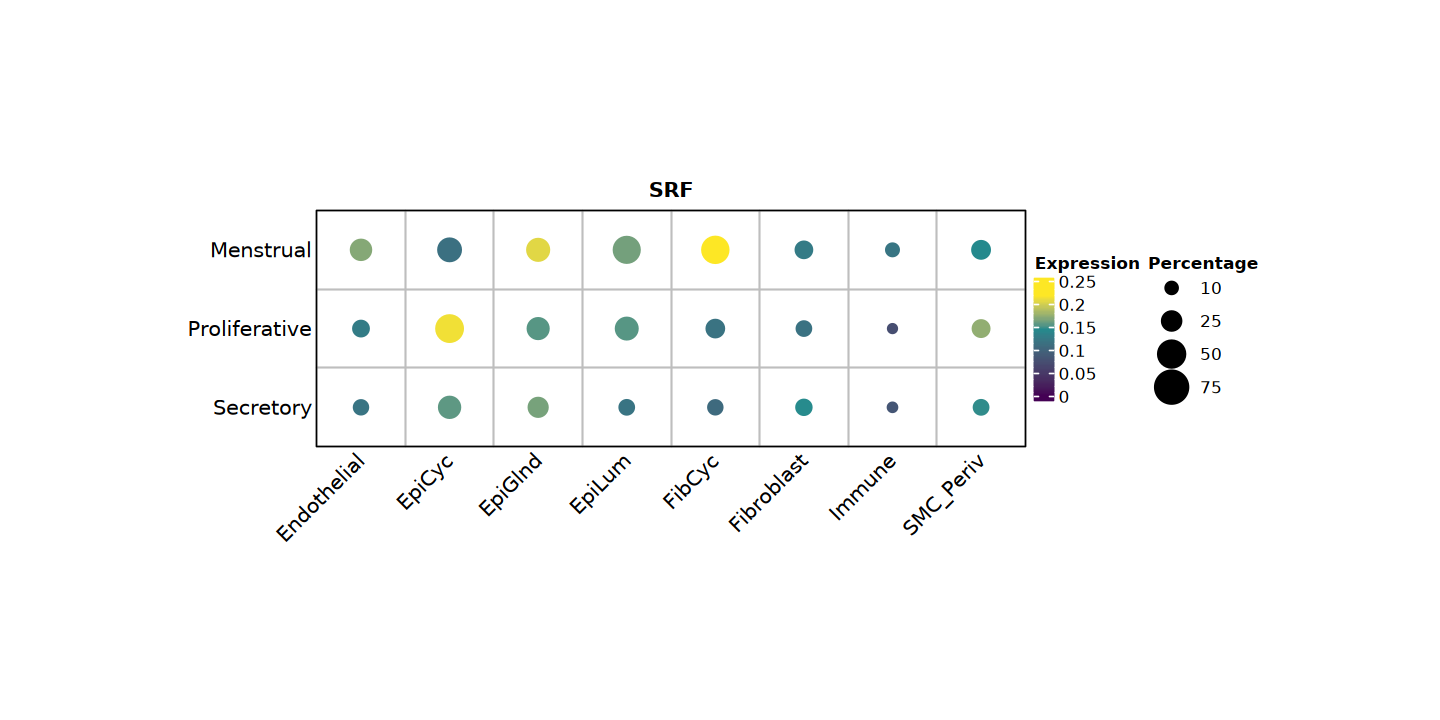

In [235]:
# Make the legend for the dot size. 
# Make sure the size is the same as the in the layer_fun which is unit(4, "mm"). You can change the size as you want.

lgd_list = list(
    Legend( labels = c(10, 25, 50, 75), title = "Percentage",
            graphics = list(
              function(x, y, w, h) grid.circle(x = x, y = y, r = sqrt(0.1)  * unit(4, "mm"),
                                               gp = gpar(fill = "black")),
              function(x, y, w, h) grid.circle(x = x, y = y, r = sqrt(0.25) * unit(4, "mm"),
                                               gp = gpar(fill = "black")),
              function(x, y, w, h) grid.circle(x = x, y = y, r = sqrt(0.5) * unit(4, "mm"),
                                               gp = gpar(fill = "black")),
              function(x, y, w, h) grid.circle(x = x, y = y, r = sqrt(0.75) * unit(4, "mm"),
                                               gp = gpar(fill = "black"))),
            labels_gp = gpar(fontsize = 10), 
            labels_rot = 0,
            legend_height = NULL, legend_width = NULL,
            title_gp = gpar(fontsize = 10, fontface = "bold"),
            row_gap = unit(3, "mm"),
            grid_width = unit(10, "mm")
            ))
    
# Now draw the plot
saved <- options(repr.plot.width = 12, repr.plot.height = 6) # Make the plots bigger from here on out, save old options
draw(hp, annotation_legend_list = lgd_list, ht_gap = unit(1, "cm"),
     annotation_legend_side = "right")
options(saved) # restore old settings

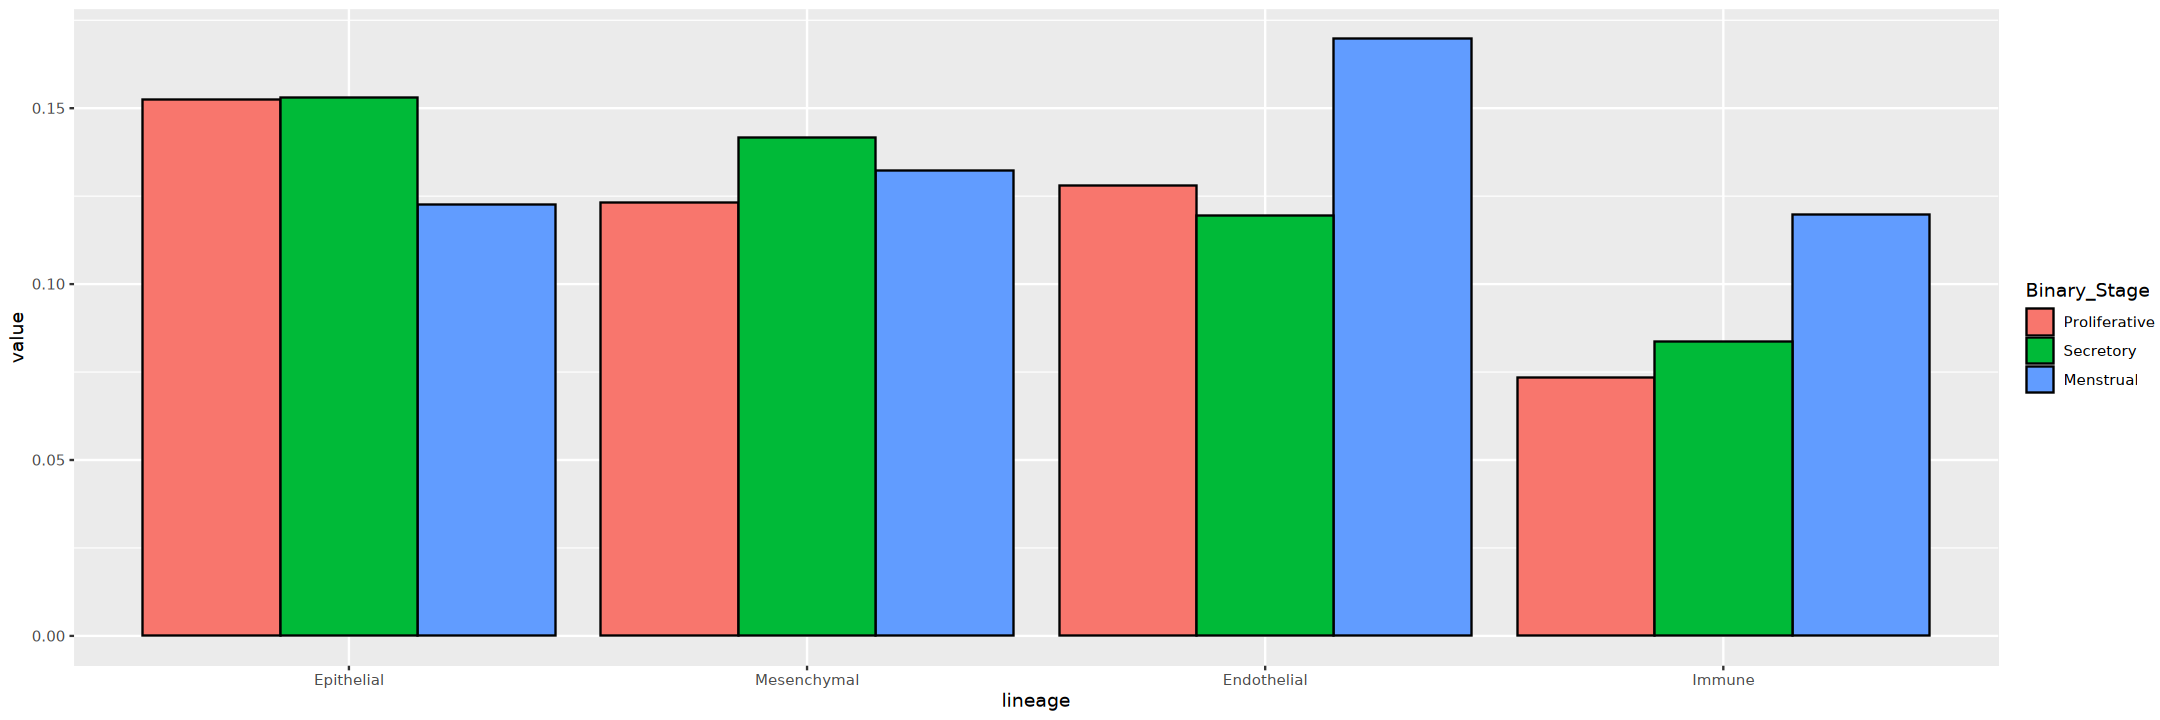

In [183]:
# Make bar plot by extracting the data per instructions found here: https://bioinformatics.stackexchange.com/questions/19531/bar-graph-of-expression-data-from-seurat-object
data.df <- hecaNH@meta.data[, c("celltypeCollapsed", "Binary_Stage")] # extracts data including cell type and phase columns
data.df["value"] <- hecaNH$RNA$data["SRF", ] # adds a column for expression value of gene of interest
data.df <- data.df %>% mutate(group = paste(lineage, Binary_Stage, sep=":")) # creases a new column called "group" with both cell type and phase information

# Optional: remove cells that do not express the gene
#data.df <- data.df %>% filter(value > 0)

# create new df with mean and sd values of the above data
data.df.2 <- data.df %>% group_by(group) %>% summarise(sd=sd(value),value=mean(value)) 

# split the "group" column data back into cell type and phase columns
X <- str_split(data.df.2$'group', ":", 2, simplify=TRUE) 
data.df.2$'lineage' <- X[, 1]
data.df.2$'Binary_Stage' <- X[, 2]

#reorder factors
data.df.2$lineage <- factor(data.df.2$lineage,levels=c("Epithelial", "Mesenchymal", "Endothelial", "Immune"))
data.df.2$Binary_Stage <- factor(data.df.2$Binary_Stage,levels=c("Proliferative", "Secretory", "Menstrual"))

# Create the bar plot
saved <- options(repr.plot.width = 18, repr.plot.height = 6) # Make the plots bigger from here on out, save old options
ggplot(data.df.2, aes(fill=Binary_Stage, y=value, x=lineage)) + 
    geom_bar(color="black", position="dodge", stat="identity")
options(saved) # restore old settings
    
#If you want to add sd error bars, add the following string after the final parenthesis above (without the quotation marks): "+ geom_errorbar(aes(ymin=value, ymax=value+sd), width=.2, position=position_dodge(.9))"

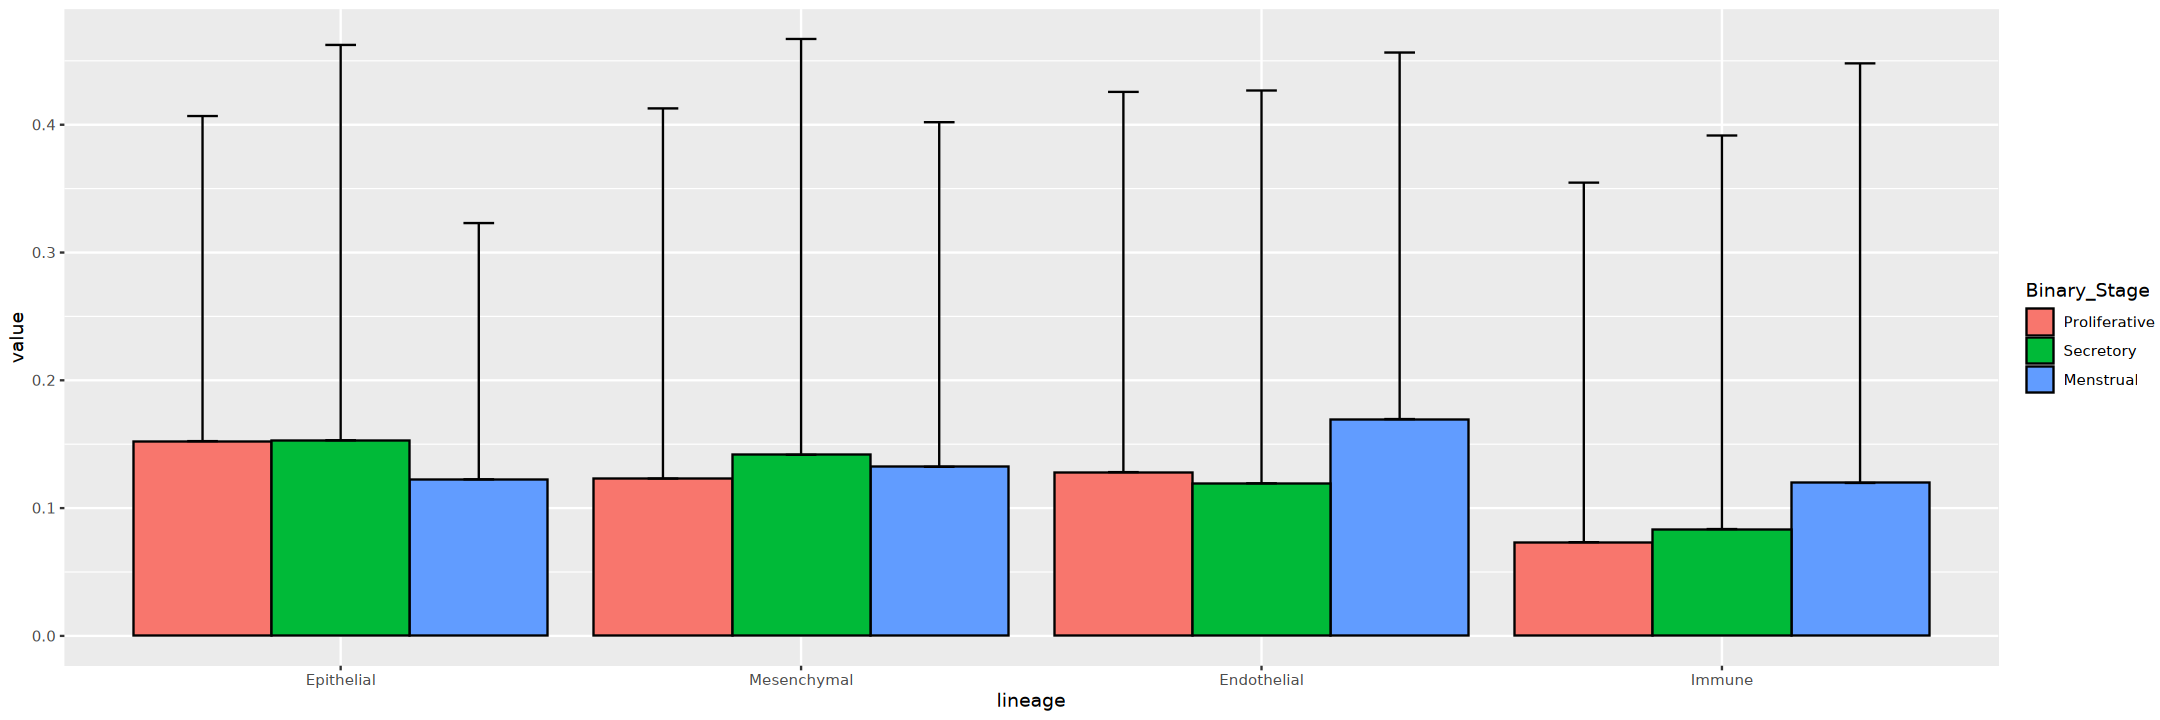

In [182]:
# Make bar plot by extracting the data per instructions found here: https://bioinformatics.stackexchange.com/questions/19531/bar-graph-of-expression-data-from-seurat-object
data.df <- hecaNH@meta.data[, c("lineage", "Binary_Stage")] # extracts data including cell type and phase columns
data.df["value"] <- hecaNH$RNA$data["SRF", ] # adds a column for expression value of gene of interest
data.df <- data.df %>% mutate(group = paste(lineage, Binary_Stage, sep=":")) # creases a new column called "group" with both cell type and phase information

# Optional: remove cells that do not express the gene
#data.df <- data.df %>% filter(value > 0)

# create new df with mean and sd values of the above data
data.df.2 <- data.df %>% group_by(group) %>% summarise(sd=sd(value),value=mean(value)) 

# split the "group" column data back into cell type and phase columns
X <- str_split(data.df.2$'group', ":", 2, simplify=TRUE) 
data.df.2$'lineage' <- X[, 1]
data.df.2$'Binary_Stage' <- X[, 2]

#reorder factors
data.df.2$lineage <- factor(data.df.2$lineage,levels=c("Epithelial", "Mesenchymal", "Endothelial", "Immune"))
data.df.2$Binary_Stage <- factor(data.df.2$Binary_Stage,levels=c("Proliferative", "Secretory", "Menstrual"))

# Create the bar plot
saved <- options(repr.plot.width = 18, repr.plot.height = 6) # Make the plots bigger from here on out, save old options
ggplot(data.df.2, aes(fill=Binary_Stage, y=value, x=lineage)) + 
    geom_bar(color="black", position="dodge", stat="identity") + geom_errorbar(aes(ymin=value, ymax=value+sd), width=.2, position=position_dodge(.9))
options(saved) # restore old settings
    


In [305]:
# Read in the processed RDS file from Sara Grimm, which contains the GD3.5 mouse (SRF flox and SRF KO) seurat object for projection to the human (HECA non-hormone treated).
# See prep code from Sara Grimm: "step4a-project_mouse_to_human-hecaNH.Rtxt"


objM2H <- readRDS("/ddn/gs1/home/marquardtrm/PRcreSRF_scRNAseq_Sara/data_rds/RM-adult_SrfKO-mouse_to_hecaNH_projection.02apr2025.rds")

objM2H
head(objM2H)


An object of class Seurat 
26486 features across 33500 samples within 1 assay 
Active assay: RNA (26486 features, 0 variable features)
 2 layers present: counts, data
 5 dimensional reductions calculated: pca, umap, integrated.rpca, ref.pca, ref.umap

,orig.ident,nCount_RNA,nFeature_RNA,Sample,genotype,batch,percent.mt,percent.rp,percent.hg,S.Score,G2M.Score,Phase,old.ident,CC.Difference,broad_cluster,CellType,CellSubtype,CellTypeBroad
,<chr>,<dbl>,<int>,<fct>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<fct>,<dbl>,<int>,<chr>,<chr>,<chr>
Ctrl1___AAACCCAAGACCATAA-1,Ctrl1,13853,4097,Ctrl1,Ctrl,1,4.858153,21.86530,0,-0.115882733,-0.10197415,G1,Ctrl1,-0.01390858,0,StromalFibroblast,StromalFibroblast,Fibroblast
Ctrl1___AAACCCAAGGTCCCGT-1,Ctrl1,5652,2163,Ctrl1,Ctrl,1,2.813163,11.34112,0,-0.087413046,-0.16113772,G1,Ctrl1,0.07372467,5,Macrophage,Macrophage,Immune
Ctrl1___AAACCCACATCACCAA-1,Ctrl1,6085,2336,Ctrl1,Ctrl,1,2.678718,10.56697,0,-0.070066492,-0.04961594,G1,Ctrl1,-0.02045055,15,gammadeltaT,gammadeltaT,Immune
Ctrl1___AAACCCACATCTAACG-1,Ctrl1,12378,3609,Ctrl1,Ctrl,1,3.869769,14.76006,0,-0.035871272,-0.09095433,G1,Ctrl1,0.05508306,11,SmoothMuscle,none,SmoothMuscle
Ctrl1___AAACCCACATGTCAGT-1,Ctrl1,15094,4189,Ctrl1,Ctrl,1,3.186697,23.22777,0,0.795792256,0.30071105,S,Ctrl1,0.49508121,10,ProliferatingNK,ProliferatingNK,Immune
Ctrl1___AAACCCAGTAATGTGA-1,Ctrl1,14440,4595,Ctrl1,Ctrl,1,4.903047,18.98199,0,0.056406385,0.58059310,G2M,Ctrl1,-0.52418671,7,ProliferatingFibroblastG2M,ProliferatingFibroblastG2M,Fibroblast
Ctrl1___AAACCCAGTGTAGGAC-1,Ctrl1,19929,4617,Ctrl1,Ctrl,1,5.996287,24.48191,0,-0.084860322,-0.12601747,G1,Ctrl1,0.04115715,3,GlandularEpithelial,GlandularEpithelial,Epithelial
Ctrl1___AAACCCATCGCCGAGT-1,Ctrl1,20720,5042,Ctrl1,Ctrl,1,4.917954,23.61004,0,-0.007086613,-0.04976484,G1,Ctrl1,0.04267823,0,StromalFibroblast,StromalFibroblast,Fibroblast
Ctrl1___AAACCCATCGGCAGTC-1,Ctrl1,15461,4527,Ctrl1,Ctrl,1,4.359356,15.99508,0,0.559701893,0.82661813,G2M,Ctrl1,-0.26691623,2,Endothelial,none,Endothelial


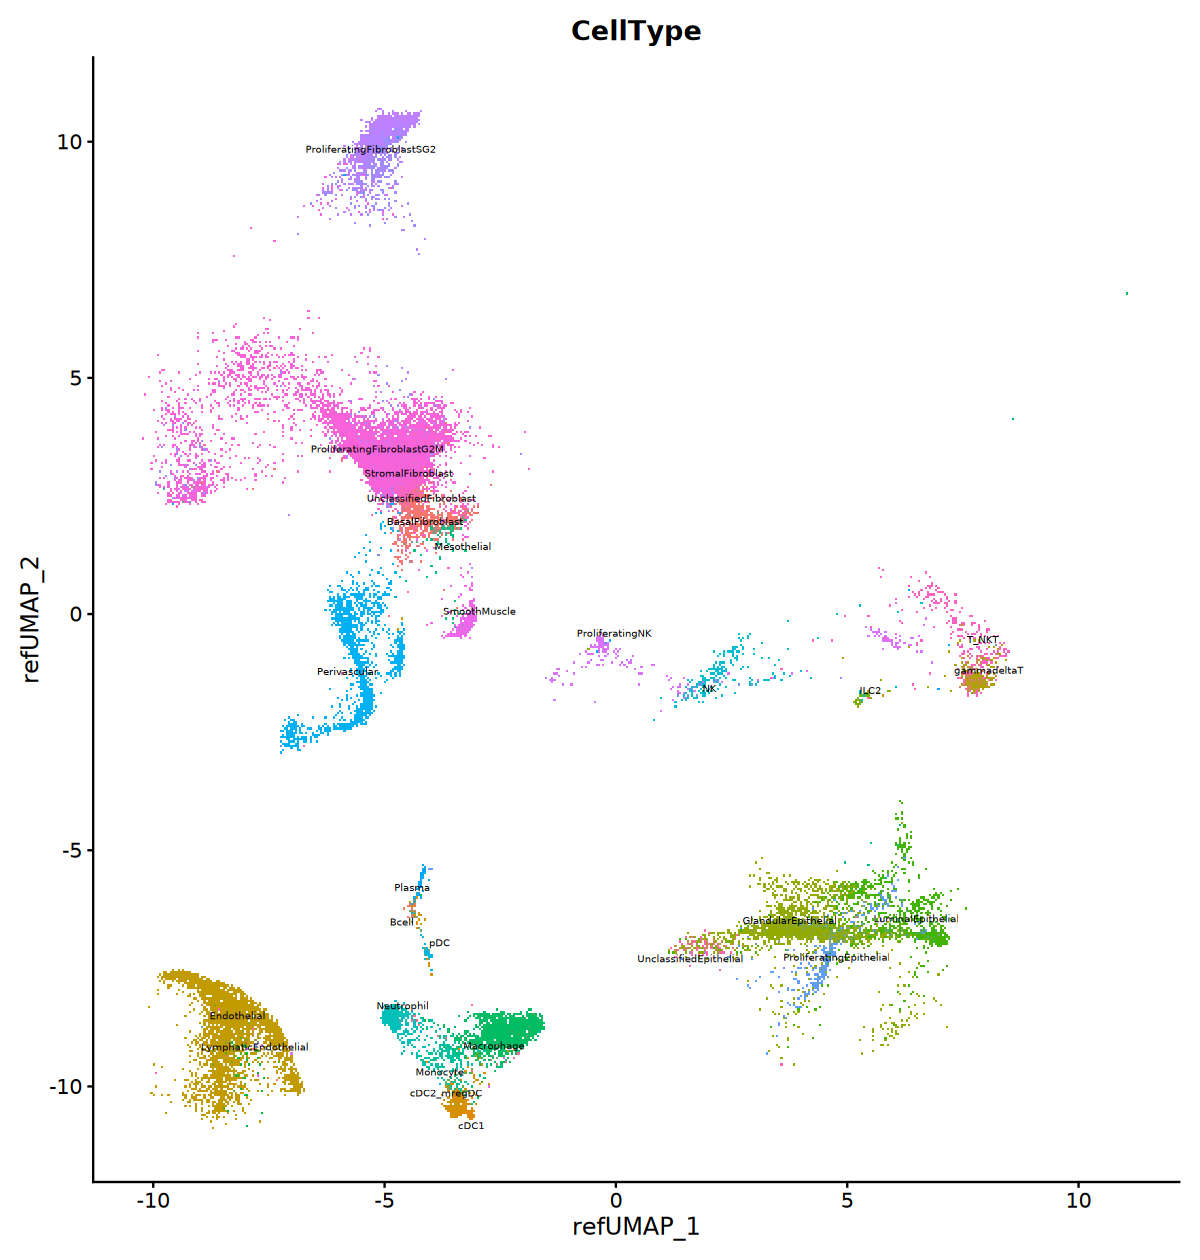

In [312]:
DimPlot(objM2H, reduction="ref.umap", group.by="CellType", label=T, label.size=2, repel=TRUE, raster=TRUE)+NoLegend();

In [313]:
levels(objM2H)

[1] "StromalFibroblast"          "Macrophage"                
 [3] "gammadeltaT"                "SmoothMuscle"              
 [5] "ProliferatingNK"            "ProliferatingFibroblastG2M"
 [7] "GlandularEpithelial"        "Endothelial"               
 [9] "Perivascular"               "cDC1"                      
[11] "ProliferatingFibroblastSG2" "UnclassifiedEpithelial"    
[13] "Mesothelial"                "BasalFibroblast"           
[15] "T_NKT"                      "cDC2_mregDC"               
[17] "LuminalEpithelial"          "Neutrophil"                
[19] "Plasma"                     "NK"                        
[21] "UnclassifiedFibroblast"     "LymphaticEndothelial"      
[23] "Bcell"                      "pDC"                       
[25] "ILC2"                       "Monocyte"                  
[27] "ProliferatingEpithelial"

In [314]:
table(objM2H$genotype,objM2H$CellType);

       
        BasalFibroblast Bcell cDC1 cDC2_mregDC Endothelial gammadeltaT
  Ctrl              632     5   54         106        2118          88
  SrfKO             372    23   84         358        1492         219
       
        GlandularEpithelial ILC2 LuminalEpithelial LymphaticEndothelial
  Ctrl                  758   11               218                   21
  SrfKO                1501   18               824                   31
       
        Macrophage Mesothelial Monocyte Neutrophil   NK  pDC Perivascular
  Ctrl         469          67        9         40   49   21         1001
  SrfKO        958          60      235        767  166  111          735
       
        Plasma ProliferatingEpithelial ProliferatingFibroblastG2M
  Ctrl      67                       1                        808
  SrfKO    137                     434                        244
       
        ProliferatingFibroblastSG2 ProliferatingNK SmoothMuscle
  Ctrl                         455             